In [ ]:
!pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.7/115.7 kB 6.4 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4031 sha256=4dcff95a6e71d27d19b80a951e5eb7a46bcccc92f2dbcf1020940b22c7d0817a
  Stored in directory: /root/.cache/pip/wheels/8b/67/f4/2caaae2146198dcb824f31a303833b07b14a5ec863fb3acd7b
Successfully built autograd-gamma


In [ ]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test
from lifelines import CoxPHFitter
from itertools import combinations
from lifelines.statistics import multivariate_logrank_test
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2
from lifelines.statistics import proportional_hazard_test

In [ ]:
#Importing Data from Arads Git-Hub directory (dataMSA - melanoma survival analysis)
dataMSA = pd.read_csv("https://raw.githubusercontent.com/aradpls/Topics-In-Statistics-Melanoma-Survival-Analysis/refs/heads/main/melanomaCSV.csv")
dataMSA

,patient,time,status,sex,age,year,thickness,ulcer
0,1,10,3,1,76,1972,6.76,1
1,2,30,3,1,56,1968,0.65,0
2,3,35,2,1,41,1977,1.34,0
3,4,99,3,0,71,1968,2.90,0
4,5,185,1,1,52,1965,12.08,1
...,...,...,...,...,...,...,...,...
200,201,4492,2,1,29,1965,7.06,1
201,202,4668,2,0,40,1965,6.12,0
202,203,4688,2,0,42,1965,0.48,0
203,204,4926,2,0,50,1964,2.26,0


In [ ]:
#Descriptive statistics
dataMSA.describe()

,patient,time,status,sex,age,year,thickness,ulcer
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,2152.800000,1.790244,0.385366,52.463415,1969.907317,2.919854,0.439024
std,59.322565,1122.060667,0.551204,0.487873,16.671711,2.575563,2.959433,0.497483
min,1.000000,10.000000,1.000000,0.000000,4.000000,1962.000000,0.100000,0.000000
25%,52.000000,1525.000000,1.000000,0.000000,42.000000,1968.000000,0.970000,0.000000
50%,103.000000,2005.000000,2.000000,0.000000,54.000000,1970.000000,1.940000,0.000000
75%,154.000000,3042.000000,2.000000,1.000000,65.000000,1972.000000,3.560000,1.000000
max,205.000000,5565.000000,3.000000,1.000000,95.000000,1977.000000,17.420000,1.000000


In [ ]:
#Data info to data type of each column
dataMSA.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   patient    205 non-null    int64  
 1   time       205 non-null    int64  
 2   status     205 non-null    int64  
 3   sex        205 non-null    int64  
 4   age        205 non-null    int64  
 5   year       205 non-null    int64  
 6   thickness  205 non-null    float64
 7   ulcer      205 non-null    int64  
dtypes: float64(1), int64(7)
memory usage: 12.9 KB


In [ ]:
#checking if thare is a emapty cells in data
dataMSA.isnull().sum()

,0
patient,0
time,0
status,0
sex,0
age,0
year,0
thickness,0
ulcer,0


In [ ]:
#Adding event col for survival anlsys cencored data
dataMSA["event"] = dataMSA["status"].replace({1:1, 2:0, 3:0})
dataMSA.head(5)

,patient,time,status,sex,age,year,thickness,ulcer,event
0,1,10,3,1,76,1972,6.76,1,0
1,2,30,3,1,56,1968,0.65,0,0
2,3,35,2,1,41,1977,1.34,0,0
3,4,99,3,0,71,1968,2.90,0,0
4,5,185,1,1,52,1965,12.08,1,1


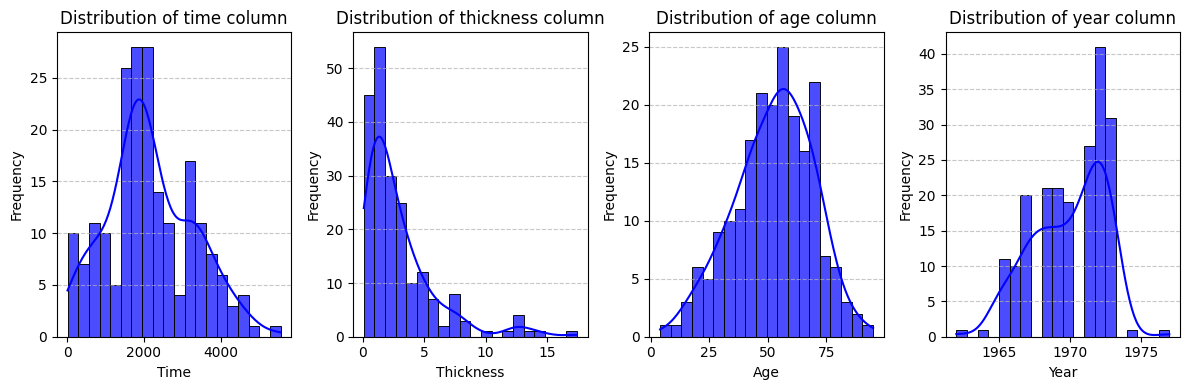

In [ ]:
#Distrubrion of none catagorial data

# Select the columns you want to analyze
columns_to_plot = ['time', 'thickness', 'age', 'year']  # Add relevant columns

# Create subplots
num_columns = len(columns_to_plot)
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(12, 4))  # Adjust grid layout
axes = axes.flatten()  # Flatten the 2D array of axes into 1D for easier iteration

# Plot each column
for idx, column in enumerate(columns_to_plot):
    sns.histplot(data=dataMSA, x=column, kde=True, bins=20, color='blue', alpha=0.7, ax=axes[idx])
    axes[idx].set_title(f'Distribution of {column} column', fontsize=12)
    axes[idx].set_xlabel(column.capitalize(), fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].grid(axis='y', linestyle='--', alpha=0.7)

# Hide any unused subplots
for i in range(len(columns_to_plot), len(axes)):
    axes[i].axis('off')

# Adjust layout
plt.tight_layout()
plt.show()


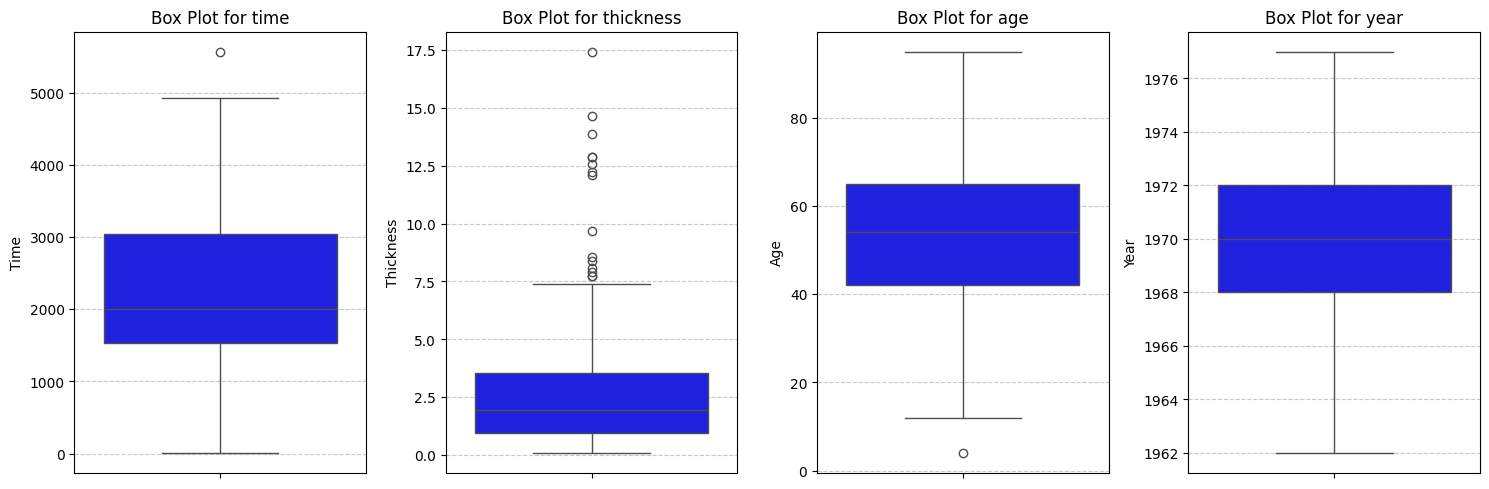

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of numerical columns to analyze
numerical_columns = ['time', 'thickness', 'age', 'year']  # Add relevant numerical columns

# Set up the matplotlib figure
plt.figure(figsize=(15, 5))

# Create a box plot for each numerical column
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(1, len(numerical_columns), i)
    sns.boxplot(data=dataMSA, y=column, color='blue')
    plt.title(f'Box Plot for {column}', fontsize=12)
    plt.ylabel(column.capitalize(), fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


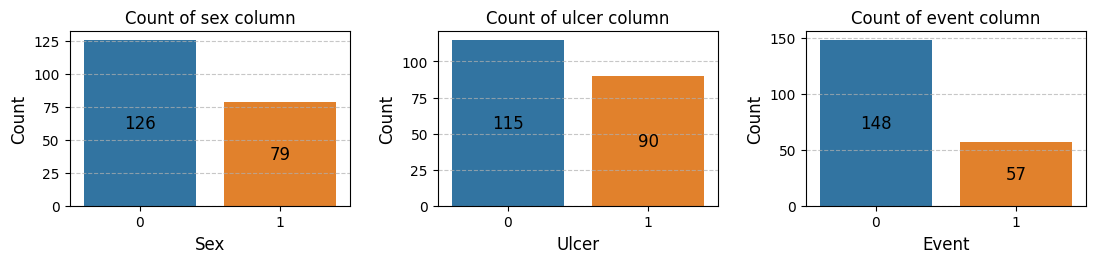

In [ ]:
#Catgorial columns (binary for now) to see simple division

# Categorical columns (binary for now) to see simple division
cat_col = ['sex', 'ulcer', 'event']

# Create a plot for each column
plt.figure(figsize=(15, 10))

# Loop through each categorical column
for i, column in enumerate(cat_col, 1):
    plt.tight_layout(pad=2.0)
    plt.subplot(4, 4, i)

    # Use countplot with default palette
    ax = sns.countplot(data=dataMSA, x=column, hue=column, legend=False)
    plt.xlabel(column.capitalize(), fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.title(f'Count of {column} column')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    # Annotate the counts on top of each bar
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                    ha='center', va='center', fontsize=12, color='black')

plt.show()


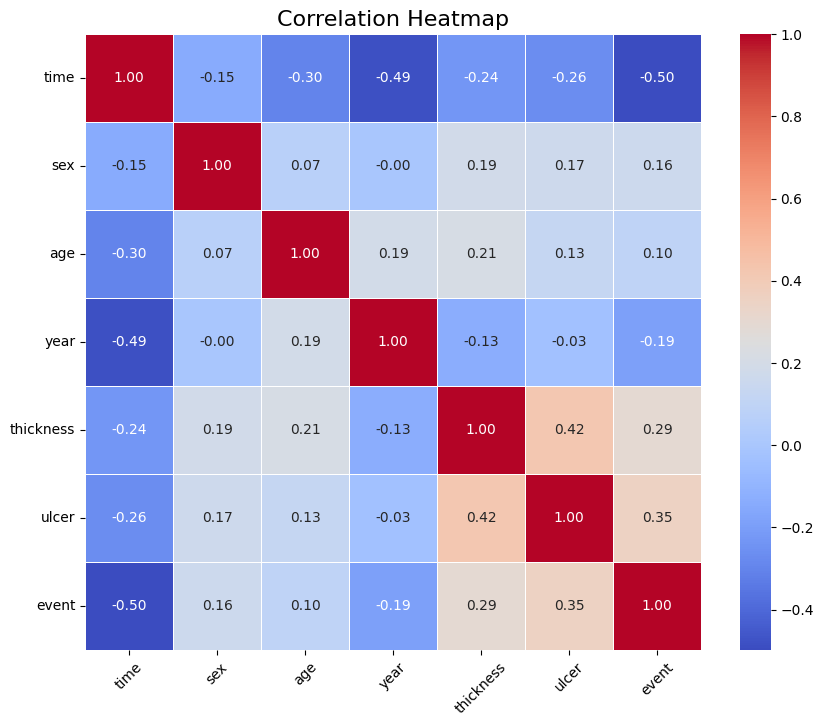

In [ ]:
#Correlation matrix
datacop = dataMSA.copy()
datacop = datacop.drop(columns =['patient', 'status'])
# Ensure numerical data is selected for correlation analysis
numerical_data = datacop.select_dtypes(include=['number'])

# Compute the correlation matrix
correlation_matrix = numerical_data.corr()

# Set up the matplotlib figure
plt.figure(figsize=(10, 8))

# Create the heatmap using seaborn
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, square=True, linewidths=0.5)

# Add titles and labels
plt.title('Correlation Heatmap', fontsize=16)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10, rotation=0)

# Show the heatmap
plt.show()


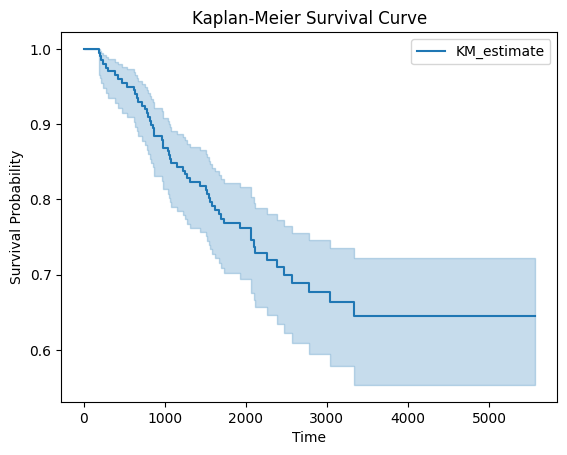

In [ ]:
#Creatin Kaplan-meir for time and event for descriptive statistics and analsys

# Initialize Kaplan-Meier fitter
kmf = KaplanMeierFitter()

# Fit the model to your data
kmf.fit(dataMSA['time'], event_observed=dataMSA['event'])

# Plot the survival curve
kmf.plot_survival_function()
plt.title('Kaplan-Meier Survival Curve')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.show()


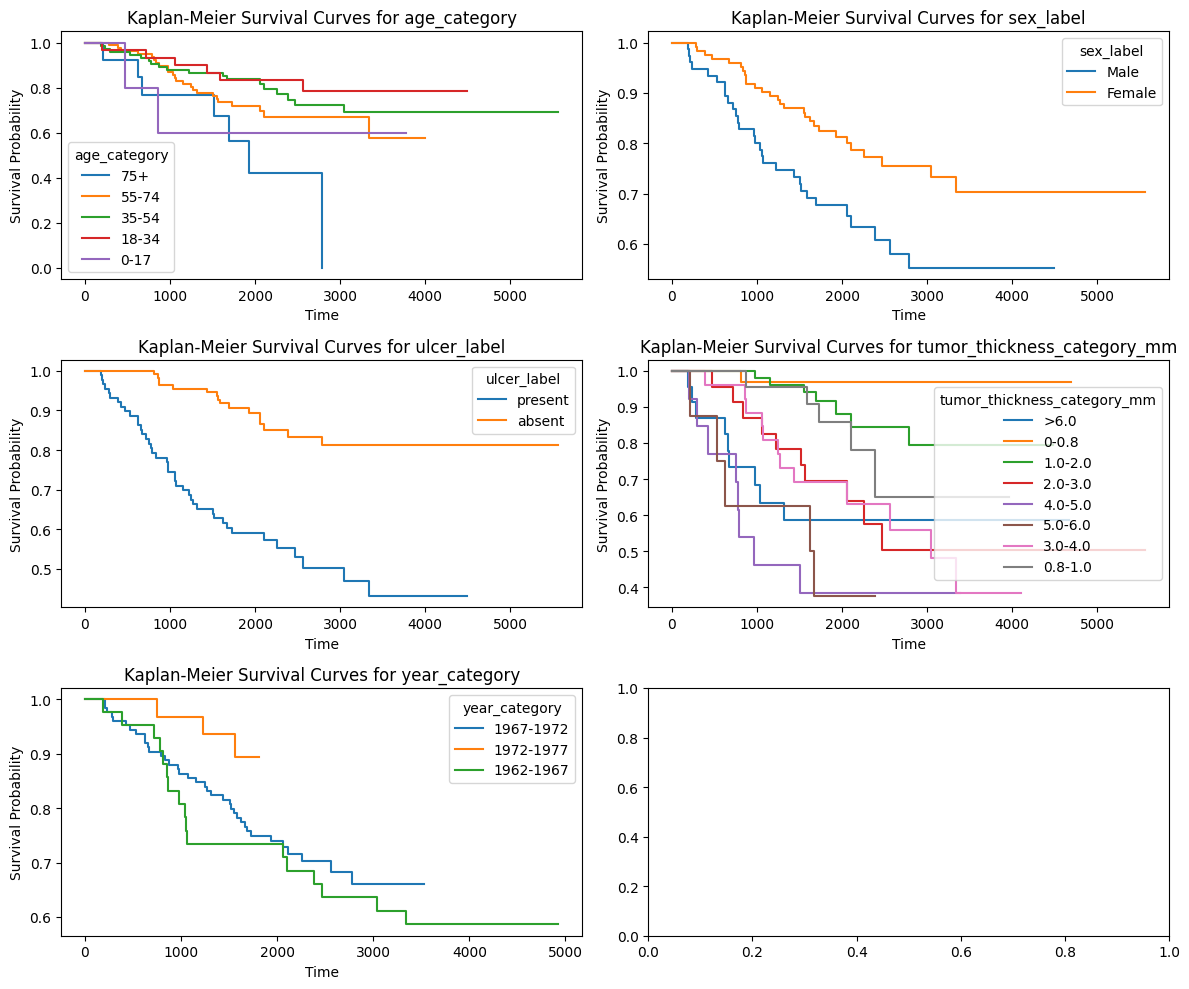

In [ ]:
#Creatin Kaplan-meir for time and event for diffrent groups

# Create Tumor Thickness Categories
#dataMSA['tumor_thickness_category_mm'] = pd.cut(dataMSA['thickness'], bins = [0, 5, 10, 15, 20], labels = ['0-5', '5-10', '10-15', '15-20'])

dataMSA['tumor_thickness_category_mm'] = pd.cut(
    dataMSA['thickness'],
    bins=[0, 0.8, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, float('inf')],
    labels=[
        '0-0.8', '0.8-1.0', '1.0-2.0', '2.0-3.0', '3.0-4.0',
        '4.0-5.0', '5.0-6.0', '>6.0'
    ]
)

# Create Age Categories
dataMSA['age_category'] = pd.cut(dataMSA['age'], bins=[0, 18, 35, 55, 75, 100], labels=['0-17', '18-34', '35-54', '55-74', '75+'])

# Create Year Categories
dataMSA['year_category'] = pd.cut(dataMSA['year'], bins=[1962, 1967, 1972, 1977], labels=['1962-1967', '1967-1972', '1972-1977'])

# Map sex values to custom labels
dataMSA['sex_label'] = dataMSA['sex'].map({1: 'Male', 0: 'Female'})
dataMSA['ulcer_label'] = dataMSA['ulcer'].map({1: 'present', 0: 'absent'})

# Columns to analyze
columns_to_test = ['age_category', 'sex_label', 'ulcer_label', 'tumor_thickness_category_mm', 'year_category']

# Set up subplots
fig, axs = plt.subplots(3, 2, figsize=(12, 10))  # Create a 3x2 grid of subplots
axs = axs.flatten()  # Flatten the 2D array of axes into a 1D array

# Loop through each column
for idx, column in enumerate(columns_to_test):
    unique_groups = dataMSA[column].dropna().unique()  # Get unique groups
    kmf = KaplanMeierFitter()

    # Plot Kaplan-Meier curves for each group in the column
    for group in unique_groups:
        group_data = dataMSA[dataMSA[column] == group]
        label = f"{group}"  # Use the group label directly for legend
        kmf.fit(group_data['time'], event_observed=group_data['event'], label=label)
        kmf.plot_survival_function(ax=axs[idx], ci_show=False)

    # Customize subplot
    axs[idx].set_title(f'Kaplan-Meier Survival Curves for {column}')
    axs[idx].set_xlabel('Time')
    axs[idx].set_ylabel('Survival Probability')
    axs[idx].legend(title=column)

# Adjust layout
plt.tight_layout()
plt.show()



In [ ]:
#Log-Rank multivariate test diffrence btween groups -
columns_to_test = ['age_category', 'sex', 'ulcer', 'tumor_thickness_category_mm', 'year_category']

for column in columns_to_test:
    results = multivariate_logrank_test(
        dataMSA['time'],
        groups=dataMSA[column],
        event_observed=dataMSA['event']
    )
    # Print the global test results
    print(f"Global Log-Rank Test for {column}:")
    print("Test statistic:", results.test_statistic)
    print("p-value:", results.p_value)
    if results.p_value < 0.05:
        print(f"  Significant differences exist between groups in {column}.")
    else:
        print(f"  No significant differences detected for {column}.")
    results.print_summary()
    print("------------------------------------------------------------------")

Global Log-Rank Test for age_category:
Test statistic: 10.794237195776004
p-value: 0.02897647665505408
  Significant differences exist between groups in age_category.


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 4
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
          10.79 0.03      5.11

------------------------------------------------------------------
Global Log-Rank Test for sex:
Test statistic: 6.467976857341599
p-value: 0.010983549936573913
  Significant differences exist between groups in sex.


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           6.47 0.01      6.51

------------------------------------------------------------------
Global Log-Rank Test for ulcer:
Test statistic: 29.56298542809486
p-value: 5.412879724223082e-08
  Significant differences exist between groups in ulcer.


...

------------------------------------------------------------------
Global Log-Rank Test for tumor_thickness_category_mm:
Test statistic: 43.22376396924915
p-value: 3.0196529197843964e-07
  Significant differences exist between groups in tumor_thickness_category_mm.


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 7
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
          43.22 <0.005     21.66

------------------------------------------------------------------
Global Log-Rank Test for year_category:
Test statistic: 3.439379941220874
p-value: 0.32870986372587024
  No significant differences detected for year_category.


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 3
         test_name = multivariate_logrank_test

---
 test_statistic    p  -log2(p)
           3.44 0.33      1.61

------------------------------------------------------------------


In [ ]:
# Examining categorical information
import pandas as pd
from itertools import combinations
from lifelines.statistics import logrank_test, multivariate_logrank_test

def logrank_pairwise(data, column):
    unique_groups = data[column].dropna().unique()

    # Perform global test
    results = multivariate_logrank_test(
        data['time'],
        groups=data[column],
        event_observed=data['event']
    )

    print(f"\nGlobal Log-Rank Test for {column}:")
    print(f"Test statistic: {results.test_statistic:.4f}, p-value: {results.p_value:.4f}")

    if results.p_value < 0.05:
        print(f"\nPairwise Log-Rank Tests for {column}:")
        merge_dict = {group: set([group]) for group in unique_groups}

        for group1, group2 in combinations(unique_groups, 2):
            group_0 = data[data[column] == group1]
            group_1 = data[data[column] == group2]

            pairwise_results = logrank_test(
                group_0['time'],
                group_1['time'],
                event_observed_A=group_0['event'],
                event_observed_B=group_1['event']
            )

            print(f"  {group1} vs {group2}: p-value = {pairwise_results.p_value:.4f}")
            if pairwise_results.p_value < 0.05:
                print(f"    Significant difference between {group1} and {group2}.")
            else:
                print(f"    No significant difference between {group1} and {group2}.")
                merge_dict[group1].add(group2)
                merge_dict[group2].add(group1)

    return data, pairwise_results

# Apply the function to your data
columns_pairwise = ['age_category', 'tumor_thickness_category_mm']

for column in columns_pairwise:
    dataMSA, pairwise_results = logrank_pairwise(dataMSA, column)


Global Log-Rank Test for age_category:
Test statistic: 10.7942, p-value: 0.0290

Pairwise Log-Rank Tests for age_category:
  75+ vs 55-74: p-value = 0.0479
    Significant difference between 75+ and 55-74.
  75+ vs 35-54: p-value = 0.0021
    Significant difference between 75+ and 35-54.
  75+ vs 18-34: p-value = 0.0044
    Significant difference between 75+ and 18-34.
  75+ vs 0-17: p-value = 0.4635
    No significant difference between 75+ and 0-17.
  55-74 vs 35-54: p-value = 0.2155
    No significant difference between 55-74 and 35-54.
  55-74 vs 18-34: p-value = 0.1484
    No significant difference between 55-74 and 18-34.
  55-74 vs 0-17: p-value = 0.6780
    No significant difference between 55-74 and 0-17.
  35-54 vs 18-34: p-value = 0.5100
    No significant difference between 35-54 and 18-34.
  35-54 vs 0-17: p-value = 0.3871
    No significant difference between 35-54 and 0-17.
  18-34 vs 0-17: p-value = 0.2437
    No significant difference between 18-34 and 0-17.

Global L

In [ ]:
# Unification of categories after pairwise comparison

dataMSA['age_category_new'] = dataMSA['age_category'].replace({'0-17': 2, '18-34': 1, '35-54': 1, '55-74': 1, '75+': 2})
dataMSA['tumor_thickness_category_mm_new'] = dataMSA['tumor_thickness_category_mm'].replace({
    '0-0.8': 1,
    '0.8-1.0': 1,
    '1.0-2.0': 1,
    '2.0-3.0': 2,
    '3.0-4.0': 2,
    '4.0-5.0': 2,
    '5.0-6.0': 2,
    '>6.0': 2
})

# dataMSA = dataMSA.drop(columns=['age_category_merged','tumor_thickness_category_mm_merged'])
dataMSA = pd.get_dummies(dataMSA, columns=['age_category_new', 'tumor_thickness_category_mm_new'], drop_first=True)
dataMSA.head(5)

<ipython-input-16-42032d3edf8e>:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataMSA['age_category_new'] = dataMSA['age_category'].replace({'0-17': 2, '18-34': 1, '35-54': 1, '55-74': 1, '75+': 2})
<ipython-input-16-42032d3edf8e>:3: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  dataMSA['age_category_new'] = dataMSA['age_category'].replace({'0-17': 2, '18-34': 1, '35-54': 1, '55-74': 1, '75+': 2})
<ipython-input-16-42032d3edf8e>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain 

,patient,time,status,sex,age,year,thickness,ulcer,event,tumor_thickness_category_mm,age_category,year_category,sex_label,ulcer_label,age_category_new_1,tumor_thickness_category_mm_new_2
0,1,10,3,1,76,1972,6.76,1,0,>6.0,75+,1967-1972,Male,present,False,True
1,2,30,3,1,56,1968,0.65,0,0,0-0.8,55-74,1967-1972,Male,absent,True,False
2,3,35,2,1,41,1977,1.34,0,0,1.0-2.0,35-54,1972-1977,Male,absent,True,False
3,4,99,3,0,71,1968,2.90,0,0,2.0-3.0,55-74,1967-1972,Female,absent,True,True
4,5,185,1,1,52,1965,12.08,1,1,>6.0,35-54,1962-1967,Male,present,True,True


In [ ]:
# Data devision for binning model and continues model
data_without_status = dataMSA.drop(columns=['status', 'sex_label', 'ulcer_label','year_category', 'year', 'patient'])
data_binning_representation_new = data_without_status.drop(columns=['age', 'thickness', 'age_category', 'tumor_thickness_category_mm'])
data_continues_representation_new = data_without_status.drop(columns=['age_category_new_1',	'tumor_thickness_category_mm_new_2', 'age_category', 'tumor_thickness_category_mm'])

# data_binning_representation_new = data_binning_representation_new.drop(columns=['sex_label', 'ulcer_label','year_category'])
# data_continues_representation_new = data_continues_representation_new.drop(columns=['year'])
# data_binning_representation_new = data_binning_representation_new.drop(columns=['year'])

In [ ]:
# VIF for the binning model
# Exclude dependent variables
predictors_bin = data_binning_representation_new

# Convert boolean columns (True/False) to numeric (1/0)
predictors_bin = predictors_bin.replace({True: 1, False: 0})

# Convert categorical variables to numeric (if applicable)
# Ensure all columns are numeric before calculating VIF
# Select only numeric columns
numeric_predictors_bin = predictors_bin.select_dtypes(include=['number'])

# Add a constant for VIF calculation
numeric_predictors_bin = numeric_predictors_bin.assign(constant=1)

# Calculate VIF for each predictor
vif_data_bin = pd.DataFrame({
    "Variable": numeric_predictors_bin.columns,
    "VIF": [variance_inflation_factor(numeric_predictors_bin.values, i) for i in range(numeric_predictors_bin.shape[1])]
})

# Drop the constant term's VIF (not relevant)
vif_data_bin = vif_data_bin[vif_data_bin["Variable"] != "constant"]

# Display VIF values
print(vif_data_bin)

                            Variable       VIF
0                               time  1.374726
1                                sex  1.068202
2                              ulcer  1.430158
3                              event  1.520394
4                 age_category_new_1  1.050996
5  tumor_thickness_category_mm_new_2  1.469929


<ipython-input-18-77885d3c97e8>:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predictors_bin = predictors_bin.replace({True: 1, False: 0})


In [ ]:
# VIF for the continues model
# Exclude dependent variables
predictors_con = data_continues_representation_new

# Convert boolean columns (True/False) to numeric (1/0)
predictors_con = predictors_con.replace({True: 1, False: 0})

# Convert categorical variables to numeric (if applicable)
# Ensure all columns are numeric before calculating VIF
# Select only numeric columns
numeric_predictors_con = predictors_con.select_dtypes(include=['number'])

# Add a constant for VIF calculation
numeric_predictors_con = numeric_predictors_con.assign(constant=1)

# Calculate VIF for each predictor
vif_data_con = pd.DataFrame({
    "Variable": numeric_predictors_con.columns,
    "VIF": [variance_inflation_factor(numeric_predictors_con.values, i) for i in range(numeric_predictors_con.shape[1])]
})

# Drop the constant term's VIF (not relevant)
vif_data_con = vif_data_con[vif_data_con["Variable"] != "constant"]

# Display VIF values
print(vif_data_con)

    Variable       VIF
0       time  1.472698
1        sex  1.057871
2        age  1.137503
3  thickness  1.308527
4      ulcer  1.323774
5      event  1.468263


In [ ]:
data_binning_representation_new

,time,sex,ulcer,event,age_category_new_1,tumor_thickness_category_mm_new_2
0,10,1,1,0,False,True
1,30,1,0,0,True,False
2,35,1,0,0,True,False
3,99,0,0,0,True,True
4,185,1,1,1,True,True
...,...,...,...,...,...,...
200,4492,1,1,0,True,True
201,4668,0,0,0,True,True
202,4688,0,0,0,True,False
203,4926,0,0,0,True,True


<ipython-input-21-3655c62dda33>:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_binning_representation_new['age_category_new_1'] = data_binning_representation_new['age_category_new_1'].replace({False: 0, True: 1})
<ipython-input-21-3655c62dda33>:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_binning_representation_new['tumor_thickness_category_mm_new_2'] = data_binning_representation_new['tumor_thickness_category_mm_new_2'].replace({False: 0, True: 1})


<lifelines.CoxPHFitter: fitted with 205 total observations, 148 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 205
number of events observed = 57
   partial log-likelihood = -260.27
         time fit was run = 2025-01-26 18:17:56 UTC

---
                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                          
sex                                0.28      1.32      0.28           -0.27            0.82                0.77                2.28
ulcer                              0.96      2.61      0.32            0.33            1.60                1.38                4.94
age_category_new_1                -0.58      0.56      0.38           -1.31            0.16                0.27                1.18
tumor_thickness_category_mm_new_2  1.09      2.96      0.35            0.40            1.77                1.49                5.87

                                   cmp to     z      p  -log2(p)
covariate                                                       
sex                                  0.00  1.00   0.32      1.67
ulcer                                0.00  2.96 <0.005      8.36
age_category_new_1                   0.00 -1.53   0.13      2.99
tumor_thickness_category_mm_new_2    0.00  3.10 <0.005      9.04
---
Concordance = 0.77
Partial AIC = 528.54
log-likelihood ratio test = 45.86 on 4 df
-log2(p) of ll-ratio test = 28.50

<Axes: >

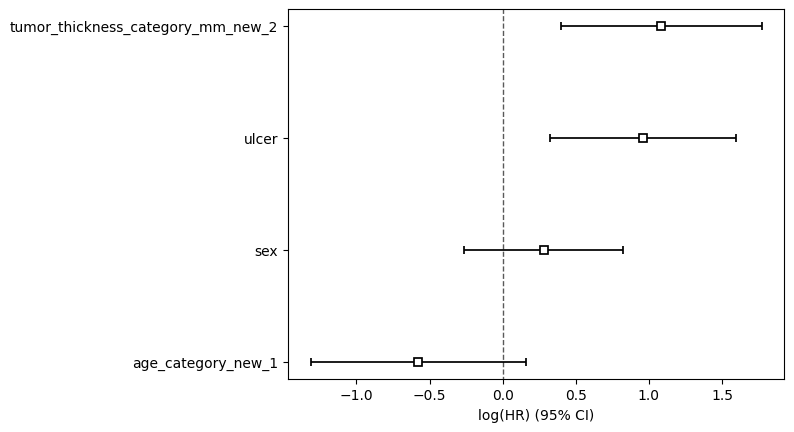

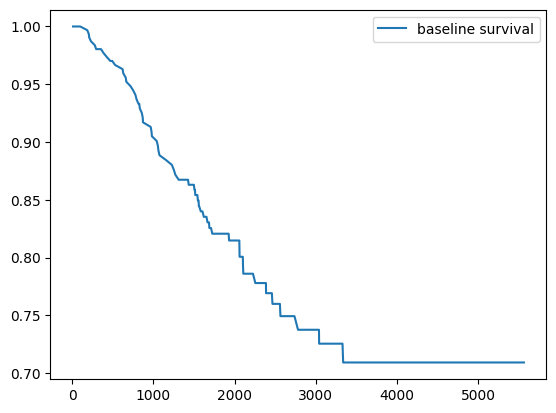

In [ ]:
# data_binning_representation_new = data_binning_representation_new.drop(columns=['sex_label', 'ulcer_label','year_category'])
# data_continues_representation_new = data_continues_representation_new.drop(columns=['year'])
# data_binning_representation_new = data_binning_representation_new.drop(columns=['year'])

#CPH regression model for binning model

# Initialize the Cox Proportional Hazards model
cph_bin = CoxPHFitter()

# Fit the model binning
data_binning_representation_new['age_category_new_1'] = data_binning_representation_new['age_category_new_1'].replace({False: 0, True: 1})
data_binning_representation_new['tumor_thickness_category_mm_new_2'] = data_binning_representation_new['tumor_thickness_category_mm_new_2'].replace({False: 0, True: 1})

cph_bin.fit(data_binning_representation_new, duration_col='time', event_col='event')

# Print the summary of results
cph_bin.print_summary()
cph_bin.plot()
cph_bin.baseline_survival_.plot()

<lifelines.CoxPHFitter: fitted with 205 total observations, 148 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 205
number of events observed = 57
   partial log-likelihood = -262.39
         time fit was run = 2025-01-26 18:17:57 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
sex        0.43      1.54      0.27           -0.09            0.96                0.91                2.60
age        0.01      1.01      0.01           -0.00            0.03                1.00                1.03
thickness  0.11      1.12      0.04            0.03            0.18                1.04                1.20
ulcer      1.16      3.20      0.31            0.56            1.77                1.75                5.88

           cmp to    z      p  -log2(p)
covariate                              
sex          0.00 1.62   0.11      3.24
age          0.00 1.47   0.14      2.82
thickness    0.00 2.89 <0.005      8.01
ulcer        0.00 3.76 <0.005     12.52
---
Concordance = 0.75
Partial AIC = 532.78
log-likelihood ratio test = 41.62 on 4 df
-log2(p) of ll-ratio test = 25.58

<Axes: >

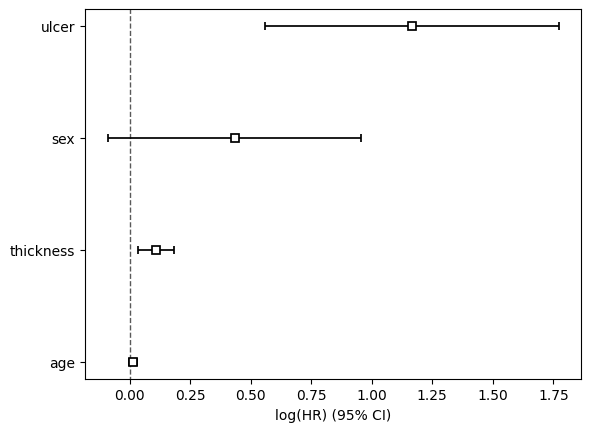

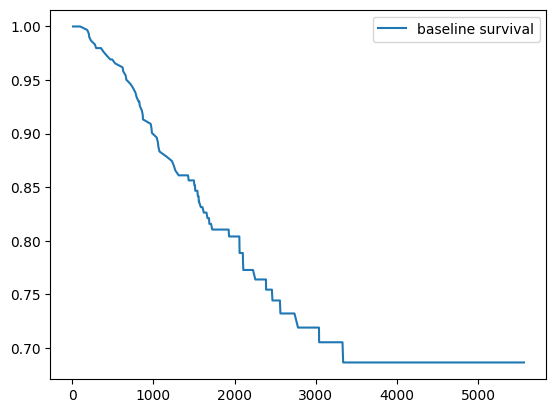

In [ ]:
# Fit the model binning for the continues model
cph_con = CoxPHFitter()

cph_con.fit(data_continues_representation_new, duration_col='time', event_col='event')
# Print the summary of results
cph_con.print_summary()
cph_con.plot()
cph_con.baseline_survival_.plot()


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.5283)'>,
  <Axes: xlabel='km-transformed time\n(p=0.5253)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2774)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3665)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.6897)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6827)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1117)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1246)'>]]

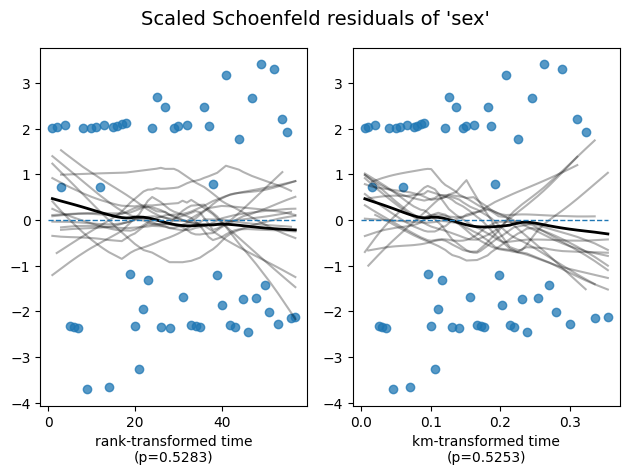

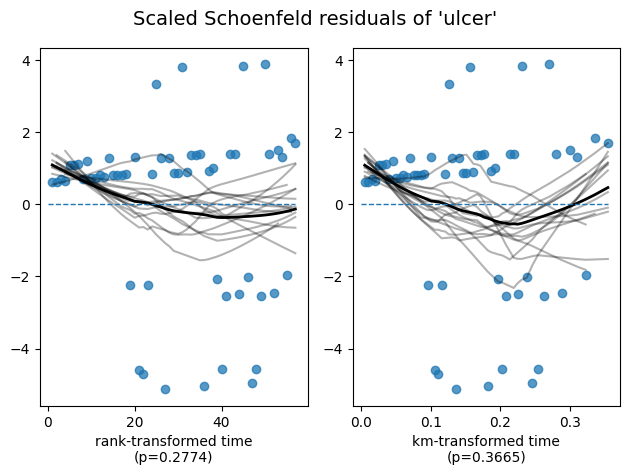

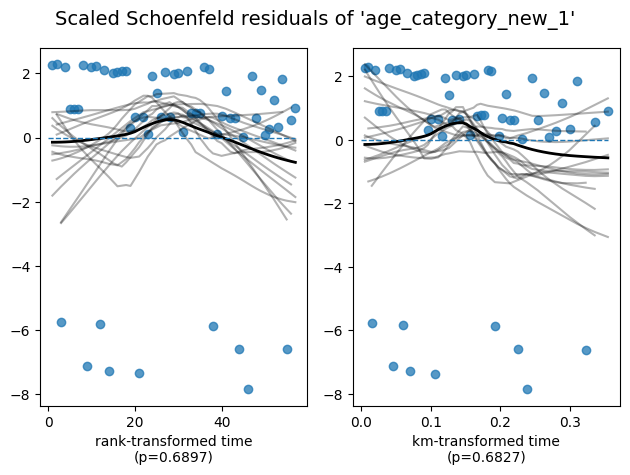

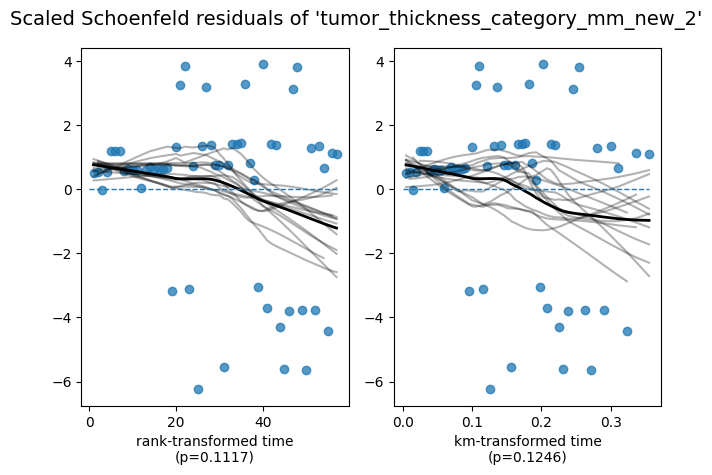

In [ ]:
#Check Residuals For Assumptions for the binning model
cph_bin.check_assumptions(data_binning_representation_new, p_value_threshold=0.05, show_plots=True)


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.2453)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2450)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0859)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0773)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0903)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0811)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1576)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2291)'>]]

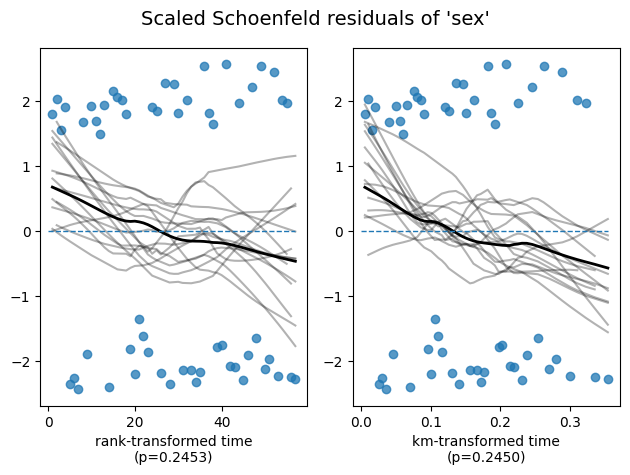

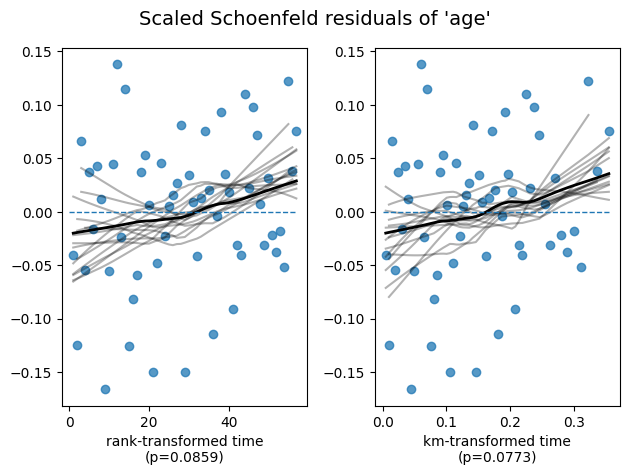

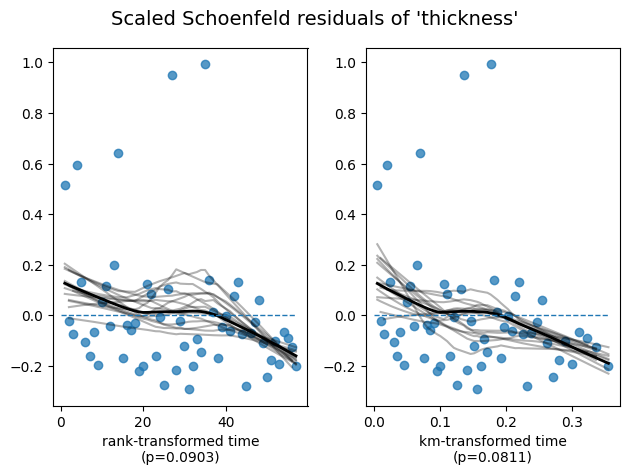

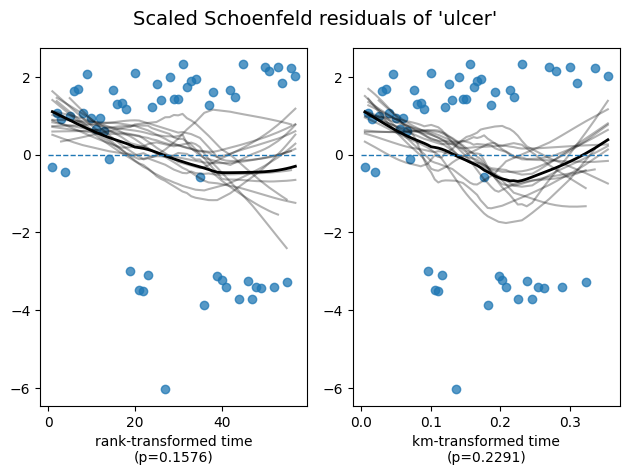

In [ ]:
#Check Residuals For Assumptions for the continues model
cph_con.check_assumptions(data_continues_representation_new, p_value_threshold=0.05, show_plots=True)

In [ ]:
# # השוואת המודלים כדי לבחור עם איזה מודל להמשיך
# למחוק כי אי אפשר לעשות השוואה בין שני מודלים באופן הזה עם מספר דרגות חופש זהה

# # Calculate the test statistic
# log_likelihood_bin = cph_bin.log_likelihood_
# log_likelihood_con = cph_con.log_likelihood_
# test_statistic = 2 * (log_likelihood_bin - log_likelihood_con)

# # Degrees of freedom is the difference in the number of parameters between the models
# if (len(cph_bin.params_) > len(cph_con.params_)):
#     degrees_of_freedom = len(cph_bin.params_)- len(cph_con.params_)
# else:
#   degrees_of_freedom = len(cph_con.params_) - len(cph_bin.params_)

# # Calculate the p-value
# p_value = chi2.sf(test_statistic, df=degrees_of_freedom)

# print(f"Likelihood Ratio Test Statistic: {test_statistic}")
# print(f"p-value: {p_value}")

In [ ]:
# Due to the previous teata results, we decided to continue with the binning model

# Backward Elimination on the binning data
def backward_elimination(data, duration_col, event_col):
    cph = CoxPHFitter()
    included_vars = list(data.columns.difference([duration_col, event_col]))
    while True:
        # Fit the model with the current variables
        cph.fit(data[[duration_col, event_col] + included_vars], duration_col=duration_col, event_col=event_col)
        pvalues = cph.summary['p']

        # Find the variable with the highest p-value
        worst_pval = pvalues.max()
        worst_var = pvalues.idxmax()

        # If the highest p-value > 0.05, remove that variable
        if worst_pval > 0.05:
            included_vars.remove(worst_var)
            print(f"Removing {worst_var} (p-value = {worst_pval:.3f})")
        else:
            break
    return included_vars

# Perform backward elimination
selected_vars = backward_elimination(data_binning_representation_new, duration_col='time', event_col='event')
print("Selected variables:", selected_vars)

Removing sex (p-value = 0.315)
Removing age_category_new_1 (p-value = 0.070)
Selected variables: ['tumor_thickness_category_mm_new_2', 'ulcer']


In [ ]:
# Perform forward elimination
def forward_elimination(data, duration_col, event_col):
    cph = CoxPHFitter()
    all_vars = list(data.columns.difference([duration_col, event_col]))
    included_vars = []

    while len(all_vars) > 0:
        best_pval = float('inf')
        best_var = None

        for var in all_vars:
            # Fit the model with current included variables plus the new variable
            temp_vars = included_vars + [var]
            cph.fit(data[[duration_col, event_col] + temp_vars], duration_col=duration_col, event_col=event_col)
            pvalue = cph.summary['p'][var]

            # Check if this variable has the lowest p-value so far
            if pvalue < best_pval:
                best_pval = pvalue
                best_var = var

        # If the best p-value < 0.05, add that variable
        if best_pval < 0.05:
            included_vars.append(best_var)
            all_vars.remove(best_var)
            print(f"Adding {best_var} (p-value = {best_pval:.3f})")
        else:
            break

    return included_vars

forward_selected_vars = forward_elimination(data_binning_representation_new, duration_col='time', event_col='event')
print("Selected variables:", forward_selected_vars)

Adding tumor_thickness_category_mm_new_2 (p-value = 0.000)
Adding ulcer (p-value = 0.002)
Selected variables: ['tumor_thickness_category_mm_new_2', 'ulcer']


In [ ]:
# The arrangement of the data after backward regression
data_after_elimantion = data_binning_representation_new.drop(columns=['sex', 'age_category_new_1'])
data_after_elimantion

,time,ulcer,event,tumor_thickness_category_mm_new_2
0,10,1,0,1
1,30,0,0,0
2,35,0,0,0
3,99,0,0,1
4,185,1,1,1
...,...,...,...,...
200,4492,1,0,1
201,4668,0,0,1
202,4688,0,0,0
203,4926,0,0,1


<lifelines.CoxPHFitter: fitted with 205 total observations, 148 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 205
number of events observed = 57
   partial log-likelihood = -262.19
         time fit was run = 2025-01-26 18:18:11 UTC

---
                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                          
ulcer                              0.99      2.69      0.32            0.36            1.62                1.44                5.04
tumor_thickness_category_mm_new_2  1.18      3.24      0.34            0.51            1.85                1.66                6.33

                                   cmp to    z      p  -log2(p)
covariate                                                      
ulcer                                0.00 3.10 <0.005      9.00
tumor_thickness_category_mm_new_2    0.00 3.44 <0.005     10.74
---
Concordance = 0.74
Partial AIC = 528.37
log-likelihood ratio test = 42.03 on 2 df
-log2(p) of ll-ratio test = 30.32

<Axes: >

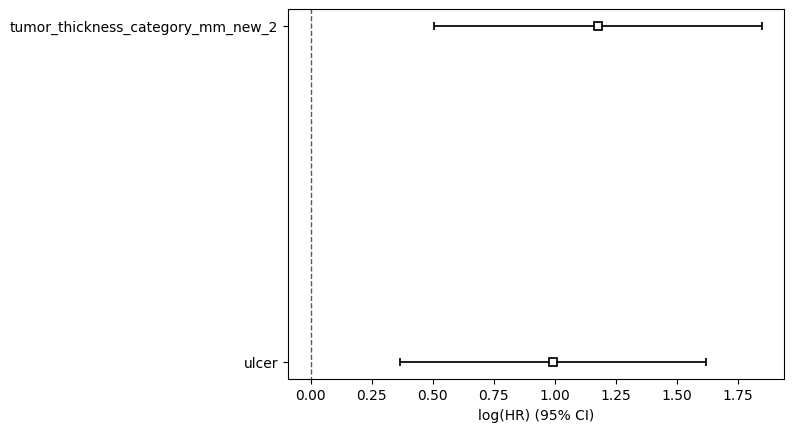

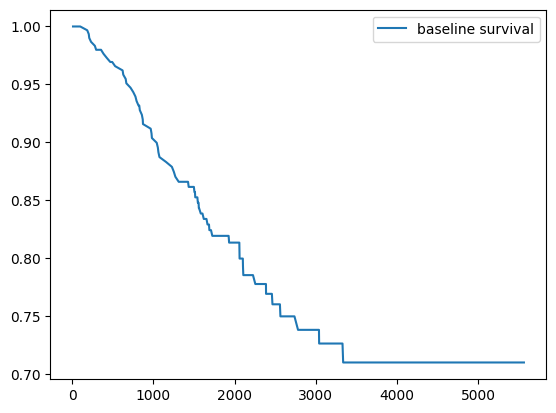

In [ ]:
# Refined model after step wise elimantion
cph_bin.fit(data_after_elimantion, duration_col='time', event_col='event')
cph_bin.print_summary()
cph_bin.plot()
cph_bin.baseline_survival_.plot()


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.0892)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1012)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2322)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3142)'>]]

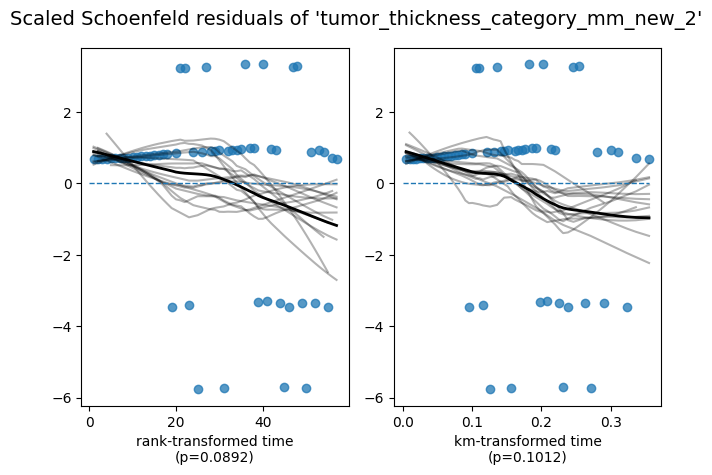

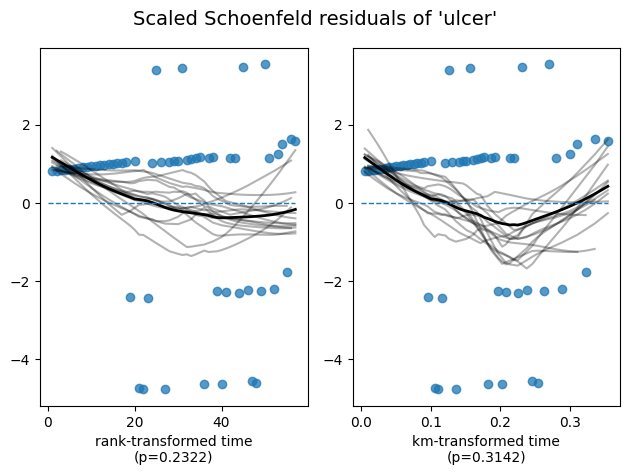

In [ ]:
# # Check Residuals For Assumptions
# # cph.check_assumptions(datanostatus[selected_vars + ['time', 'event']], p_value_threshold=0.05, show_plots=True)
# cph_bin.check_assumptions(data_binning_representation_new[selected_vars + ['time', 'event']], p_value_threshold=0.05, show_plots=True)

#Refit the model with the selected variables to check assumptions
cph_bin.fit(data_binning_representation_new[['time', 'event'] + selected_vars], duration_col='time', event_col='event')

#Then check the assumptions:
cph_bin.check_assumptions(data_binning_representation_new[['time', 'event'] + selected_vars], p_value_threshold=0.05, show_plots=True)

In [ ]:
# Create interaction terms - before elimination full model

interaction_data = dataMSA.drop(columns=['patient', 'status', 'age', 'thickness', 'tumor_thickness_category_mm', 'age_category', 'sex_label', 'ulcer_label'])
interaction_data['age_category_new_1'] = interaction_data['age_category_new_1'].replace({True: 1, False: 0})
interaction_data['tumor_thickness_category_mm_new_2'] = interaction_data['tumor_thickness_category_mm_new_2'].replace({True: 1, False: 0})

# Convert 'year_category' to a numerical representation
interaction_data['year_category'] = interaction_data['year_category'].cat.codes

interaction_data['sex_age_interaction'] = interaction_data['sex'] * interaction_data['age_category_new_1']
interaction_data['sex_year_interaction'] = interaction_data['sex'] * interaction_data['year_category']
interaction_data['sex_thickness_interaction'] = interaction_data['sex'] * interaction_data['tumor_thickness_category_mm_new_2']
interaction_data['sex_ulcer_interaction'] = interaction_data['sex'] * interaction_data['ulcer']

# interaction_data['age_year_interaction'] = interaction_data['age_category_new_1'] * interaction_data['year']
interaction_data['age_year_interaction'] = interaction_data['age_category_new_1'] * interaction_data['year_category']
interaction_data['age_thickness_interaction'] = interaction_data['age_category_new_1'] * interaction_data['tumor_thickness_category_mm_new_2']
interaction_data['age_ulcer_interaction'] = interaction_data['age_category_new_1'] * interaction_data['ulcer']

# interaction_data['thickness_year_interaction'] = interaction_data['tumor_thickness_category_mm_new_2'] * interaction_data['year']
interaction_data['thickness_year_interaction'] = interaction_data['tumor_thickness_category_mm_new_2'] * interaction_data['year_category']
interaction_data['thickness_ulcer_interaction'] = interaction_data['tumor_thickness_category_mm_new_2'] * interaction_data['ulcer']

# interaction_data['ulcer_year_interaction'] = interaction_data['ulcer'] * interaction_data['year']
interaction_data['ulcer_year_interaction'] = interaction_data['ulcer'] * interaction_data['year_category']

# interaction_data['sex_age_year_interaction'] = interaction_data['sex'] * interaction_data['age_category_new_1'] * interaction_data['year']
interaction_data['sex_age_year_interaction'] = interaction_data['sex'] * interaction_data['age_category_new_1'] * interaction_data['year_category']
interaction_data['sex_age_thickness_interaction'] = interaction_data['sex'] * interaction_data['age_category_new_1'] * interaction_data['tumor_thickness_category_mm_new_2']
interaction_data['sex_age_ulcer_interaction'] = interaction_data['sex'] * interaction_data['age_category_new_1'] * interaction_data['ulcer']
# interaction_data['sex_year_thickness_interaction'] = interaction_data['sex'] * interaction_data['year'] * interaction_data['tumor_thickness_category_mm_new_2']
interaction_data['sex_year_thickness_interaction'] = interaction_data['sex'] * interaction_data['year_category'] * interaction_data['tumor_thickness_category_mm_new_2']
# interaction_data['sex_year_ulcer_interaction'] = interaction_data['sex'] * interaction_data['year'] * interaction_data['ulcer']
interaction_data['sex_year_ulcer_interaction'] = interaction_data['sex'] * interaction_data['year_category'] * interaction_data['ulcer']
interaction_data['sex_thickness_ulcer_interaction'] = interaction_data['sex'] * interaction_data['tumor_thickness_category_mm_new_2'] * interaction_data['ulcer']

# interaction_data['age_year_thickness_interaction'] = interaction_data['age_category_new_1'] * interaction_data['year'] * interaction_data['tumor_thickness_category_mm_new_2']
# interaction_data['age_year_ulcer_interaction'] = interaction_data['age_category_new_1'] * interaction_data['year'] * interaction_data['ulcer']
interaction_data['age_year_thickness_interaction'] = interaction_data['age_category_new_1'] * interaction_data['year_category'] * interaction_data['tumor_thickness_category_mm_new_2']
interaction_data['age_year_ulcer_interaction'] = interaction_data['age_category_new_1'] * interaction_data['year_category'] * interaction_data['ulcer']
interaction_data['age_thickness_ulcer_interaction'] = interaction_data['age_category_new_1'] * interaction_data['tumor_thickness_category_mm_new_2'] * interaction_data['ulcer']

# interaction_data['year_thickness_ulcer_interaction'] = interaction_data['year'] * interaction_data['tumor_thickness_category_mm_new_2'] * interaction_data['ulcer']
interaction_data['year_thickness_ulcer_interaction'] = interaction_data['year_category'] * interaction_data['tumor_thickness_category_mm_new_2'] * interaction_data['ulcer']

# interaction_data['sex_age_year_thickness_interaction'] = interaction_data['sex'] * interaction_data['age_category_new_1'] * interaction_data['year'] * interaction_data['tumor_thickness_category_mm_new_2']
# interaction_data['sex_age_year_ulcer_interaction'] = interaction_data['sex'] * interaction_data['age_category_new_1'] * interaction_data['year'] * interaction_data['ulcer']
# interaction_data['sex_year_thickness_ulcer_interaction'] = interaction_data['sex'] * interaction_data['year'] * interaction_data['tumor_thickness_category_mm_new_2'] * interaction_data['ulcer']
# interaction_data['sex_age_thickness_ulcer_interaction'] = interaction_data['sex'] * interaction_data['age_category_new_1'] * interaction_data['tumor_thickness_category_mm_new_2'] * interaction_data['ulcer']

# interaction_data['age_year_thickness_ulcer_interaction'] = interaction_data['age_category_new_1'] * interaction_data['year'] * interaction_data['tumor_thickness_category_mm_new_2'] * interaction_data['ulcer']

# interaction_data['all_interaction'] = interaction_data['sex'] * interaction_data['age_category_new_1'] * interaction_data['year'] * interaction_data['tumor_thickness_category_mm_new_2'] * interaction_data['ulcer']

<ipython-input-31-5f2602859d45>:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  interaction_data['age_category_new_1'] = interaction_data['age_category_new_1'].replace({True: 1, False: 0})
<ipython-input-31-5f2602859d45>:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  interaction_data['tumor_thickness_category_mm_new_2'] = interaction_data['tumor_thickness_category_mm_new_2'].replace({True: 1, False: 0})


<lifelines.CoxPHFitter: fitted with 205 total observations, 148 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 205
number of events observed = 57
   partial log-likelihood = -271.48
         time fit was run = 2025-01-26 18:18:13 UTC

---
                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                          
sex                                0.75      2.11      3.05           -5.23            6.73                0.01              837.30
age_category_new_1                -0.32      0.73      1.56           -3.38            2.75                0.03               15.62
year                              -0.01      0.99      0.11           -0.23            0.21                0.80                1.23
tumor_thickness_category_mm_new_2  0.74      2.09      2.42           -4.00            5.47                0.02              238.02
ulcer                             -2.74      0.06      4.53          -11.63            6.14                0.00              463.20
sex_age_interaction               -0.64      0.53      3.09           -6.70            5.41                0.00              223.46
sex_year_interaction              -0.60      0.55      2.15           -4.81            3.62                0.01               37.26
sex_thickness_interaction         -0.37      0.69      3.56           -7.35            6.60                0.00              736.84
sex_ulcer_interaction             -0.85      0.43      3.82           -8.33            6.63                0.00              757.87
age_year_interaction               0.02      1.02      0.54           -1.04            1.08                0.35                2.93
age_thickness_interaction         -0.70      0.49      2.50           -5.60            4.19                0.00               65.98
age_ulcer_interaction              2.77     15.91      4.46           -5.98           11.51                0.00            1.00e+05
thickness_year_interaction        -1.09      0.34      2.53           -6.04            3.86                0.00               47.54
thickness_ulcer_interaction        2.03      7.62      3.67           -5.17            9.23                0.01            10227.51
ulcer_year_interaction             2.42     11.28      3.61           -4.65            9.50                0.01            13308.08
sex_age_year_interaction           0.51      1.66      2.19           -3.78            4.80                0.02              121.84
sex_age_thickness_interaction      0.24      1.27      3.41           -6.44            6.92                0.00             1008.49
sex_age_ulcer_interaction          1.06      2.87      3.29           -5.40            7.51                0.00             1825.13
sex_year_thickness_interaction     0.27      1.30      1.41           -2.49            3.03                0.08               20.60
sex_year_ulcer_interaction        -0.26      0.77      1.45           -3.10            2.58                0.05               13.26
sex_thickness_ulcer_interaction   -0.00      1.00      1.45           -2.85            2.85                0.06               17.22
age_year_thickness_interaction     1.11      3.05      2.61           -4.01            6.24                0.02              512.48
age_year_ulcer_interaction        -2.37      0.09      3.48           -9.20            4.46                0.00               86.12
age_thickness_ulcer_interaction   -1.78      0.17      3.58           -8.79            5.23                0.00              186.89
year_thickness_ulcer_interaction  -0.11      0.89      1.20           -2.46            2.24                0.09                9.38

                                   cmp to     z    p  -log2(p)
covariate       

<Axes: >

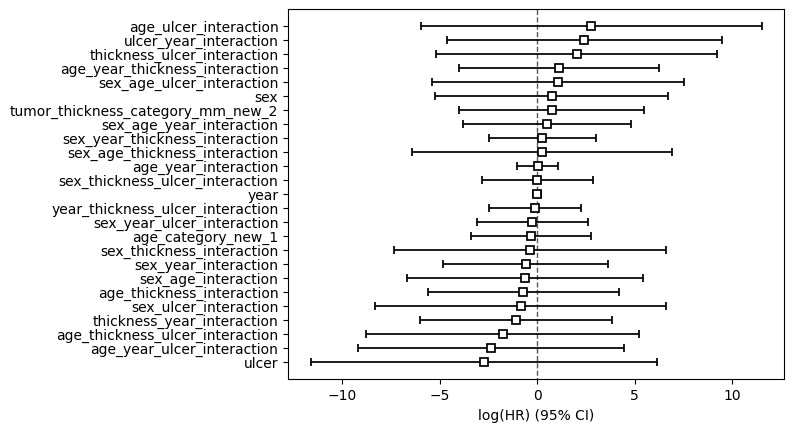

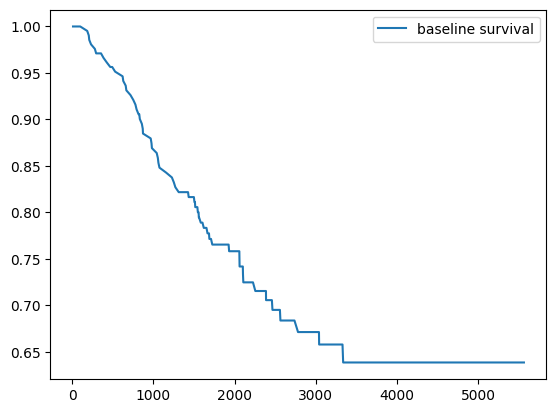

In [ ]:
# Fit the model with interaction terms - before elimination full model
interaction_columns = ['sex', 'age_category_new_1', 'year', 'tumor_thickness_category_mm_new_2', 'ulcer',
                       'sex_age_interaction', 'sex_year_interaction', 'sex_thickness_interaction', 'sex_ulcer_interaction',
                       'age_year_interaction', 'age_thickness_interaction', 'age_ulcer_interaction',
                       'thickness_year_interaction', 'thickness_ulcer_interaction',
                       'ulcer_year_interaction',
                       'sex_age_year_interaction', 'sex_age_thickness_interaction', 'sex_age_ulcer_interaction', 'sex_year_thickness_interaction', 'sex_year_ulcer_interaction', 'sex_thickness_ulcer_interaction',
                       'age_year_thickness_interaction', 'age_year_ulcer_interaction', 'age_thickness_ulcer_interaction',
                       'year_thickness_ulcer_interaction']
                      #  'sex_age_year_thickness_interaction', 'sex_age_year_ulcer_interaction', 'sex_year_thickness_ulcer_interaction', 'sex_age_thickness_ulcer_interaction',
                      #  'age_year_thickness_ulcer_interaction',
                      #  'all_interaction']

# interaction_data
cph_interaction = CoxPHFitter()
cph_interaction.fit(interaction_data[interaction_columns + ['time', 'event']], duration_col='time', event_col='event')
cph_interaction.print_summary()
cph_interaction.plot()
cph_interaction.baseline_survival_.plot()

<lifelines.CoxPHFitter: fitted with 205 total observations, 148 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 205
number of events observed = 57
   partial log-likelihood = -261.81
         time fit was run = 2025-01-26 18:18:14 UTC

---
                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                          
tumor_thickness_category_mm_new_2  0.86      2.37      0.50           -0.13            1.85                0.88                6.37
ulcer                              0.57      1.77      0.60           -0.61            1.75                0.55                5.75
thickness_ulcer_interaction        0.62      1.86      0.73           -0.81            2.05                0.44                7.76

                                   cmp to    z    p  -log2(p)
covariate                                                    
tumor_thickness_category_mm_new_2    0.00 1.71 0.09      3.52
ulcer                                0.00 0.95 0.34      1.55
thickness_ulcer_interaction          0.00 0.85 0.40      1.33
---
Concordance = 0.74
Partial AIC = 529.62
log-likelihood ratio test = 42.78 on 3 df
-log2(p) of ll-ratio test = 28.44

<Axes: >

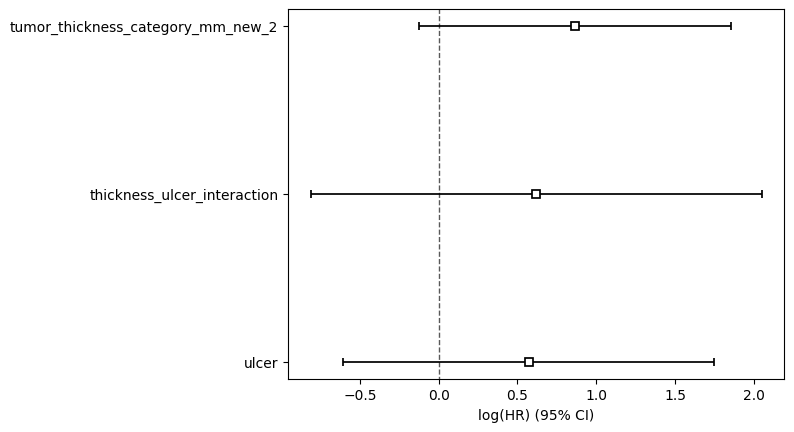

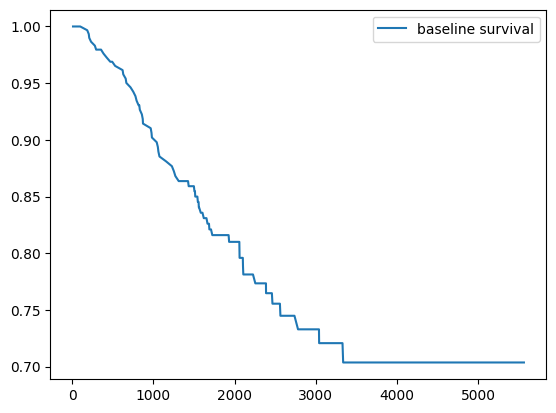

In [ ]:
# Create interaction terms - before elimination partial model
data_after_elimantion['thickness_ulcer_interaction'] = data_after_elimantion['tumor_thickness_category_mm_new_2'] * data_after_elimantion['ulcer']

# Fit the model with interaction terms - after elimination partial model
interaction_columns_elimination = ['tumor_thickness_category_mm_new_2', 'ulcer', 'thickness_ulcer_interaction']

cph_interaction_elimination = CoxPHFitter()
cph_interaction_elimination.fit(data_after_elimantion[interaction_columns_elimination + ['time', 'event']], duration_col='time', event_col='event')
cph_interaction_elimination.print_summary()
cph_interaction_elimination.plot()
cph_interaction_elimination.baseline_survival_.plot()


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lin

/usr/local/lib/python3.11/dist-packages/lifelines/fitters/mixins.py:123: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()



   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.4398)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3299)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.1270)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1613)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.4153)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3683)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.2969)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3217)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.9770)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9781)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7963)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6534)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.4113)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3499)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.5429)'>,
  <Axes: xlabel='km-transformed time\n(p=0.4748)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8894)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9862)'>],
 [<Axes: xlabel='rank-transformed tim

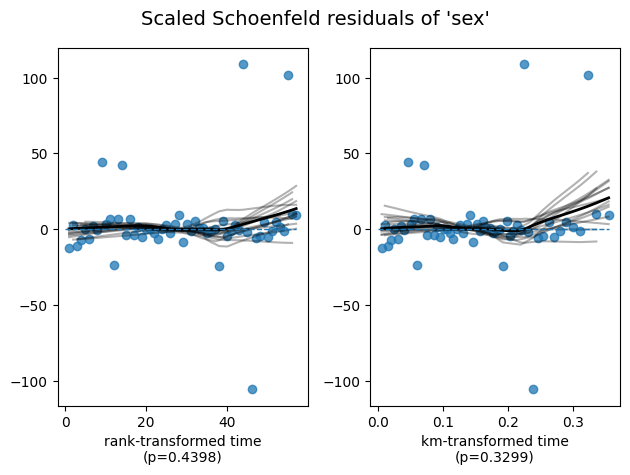

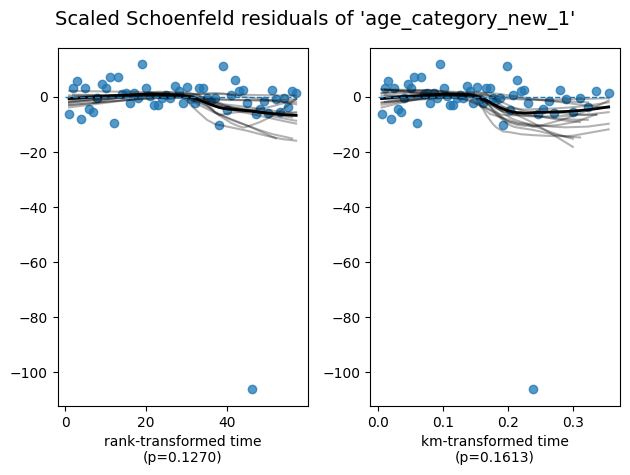

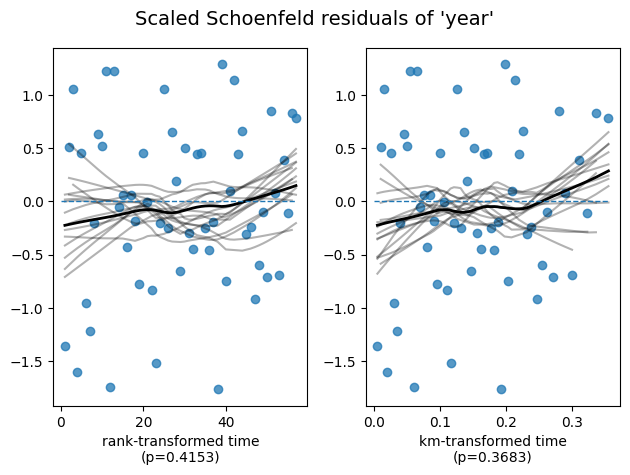

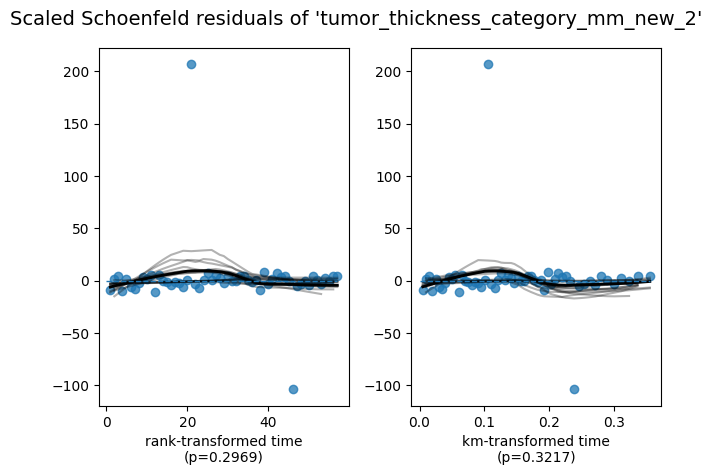

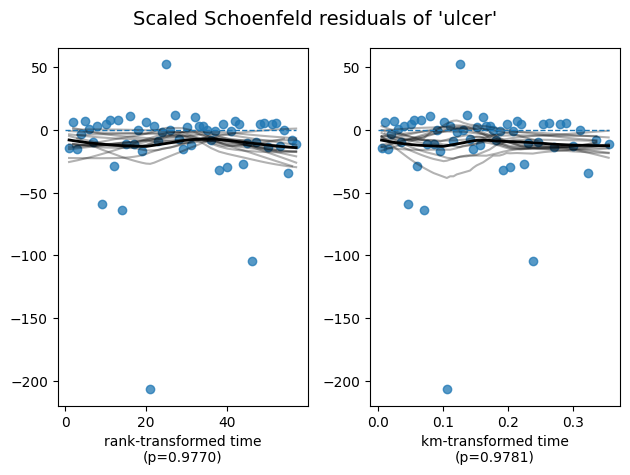

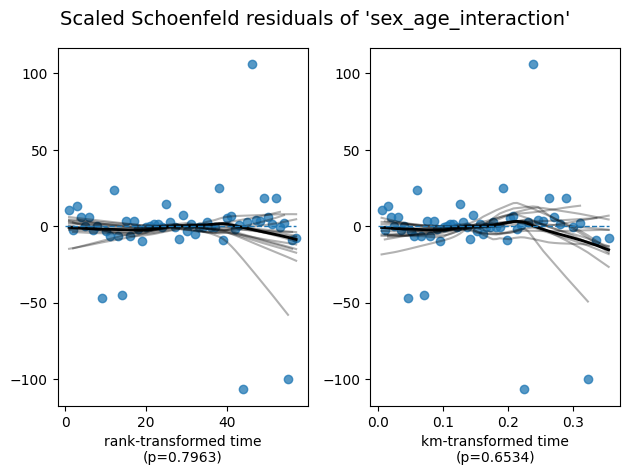

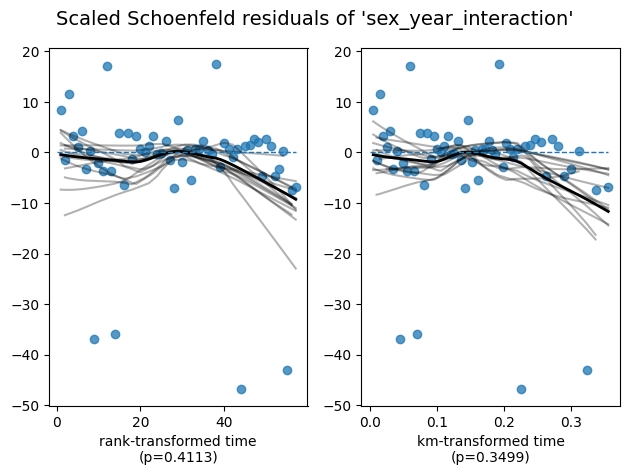

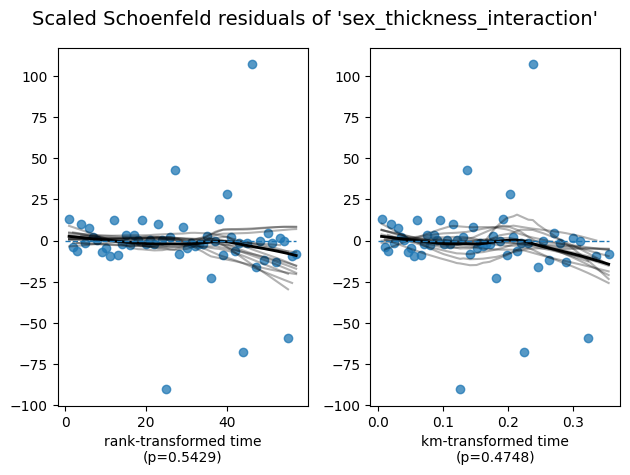

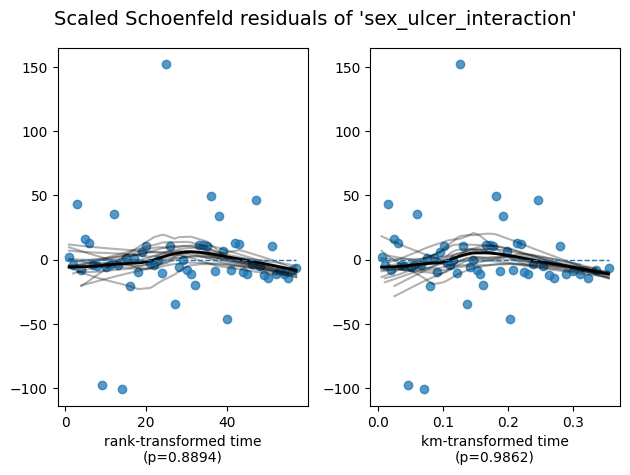

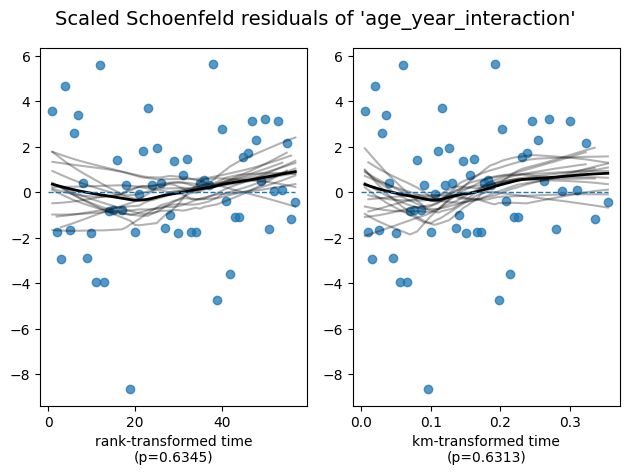

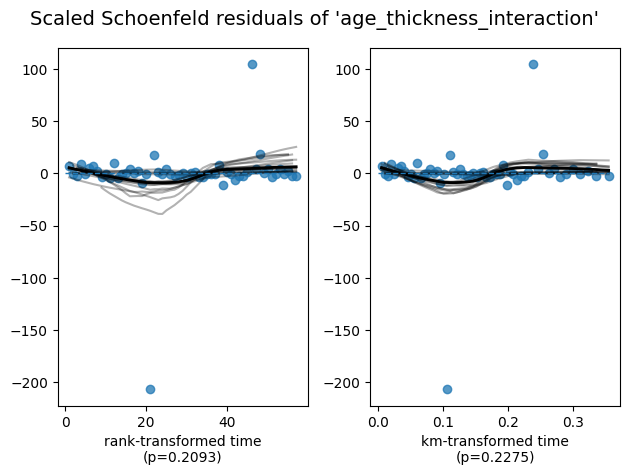

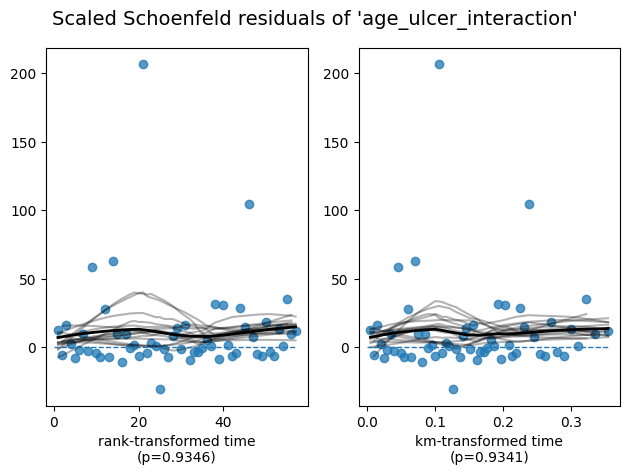

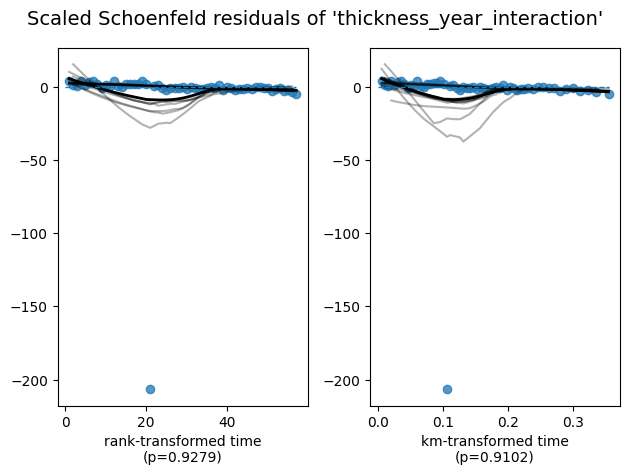

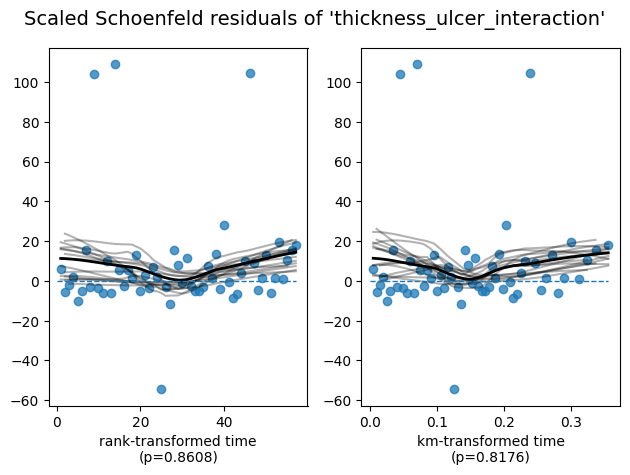

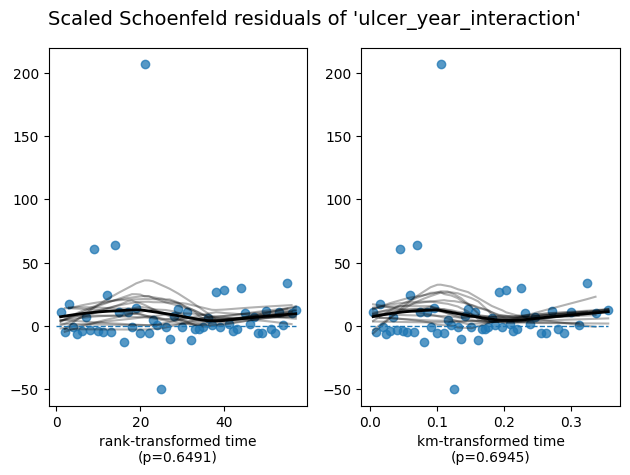

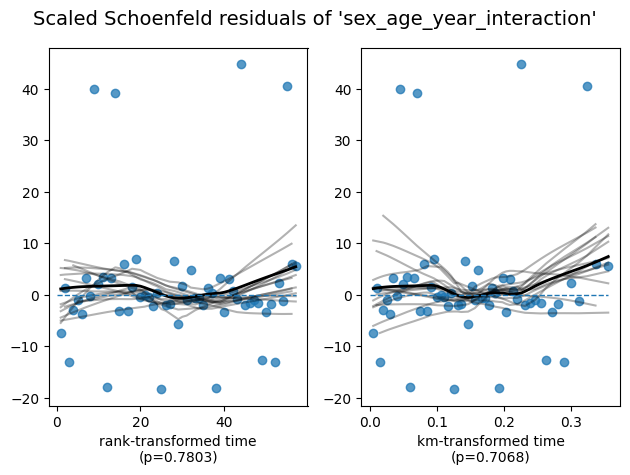

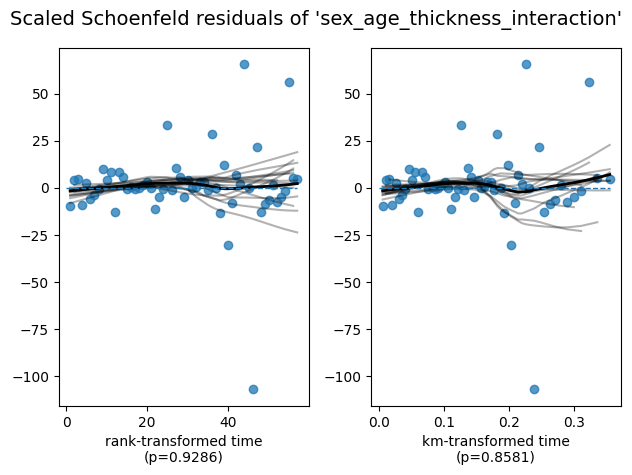

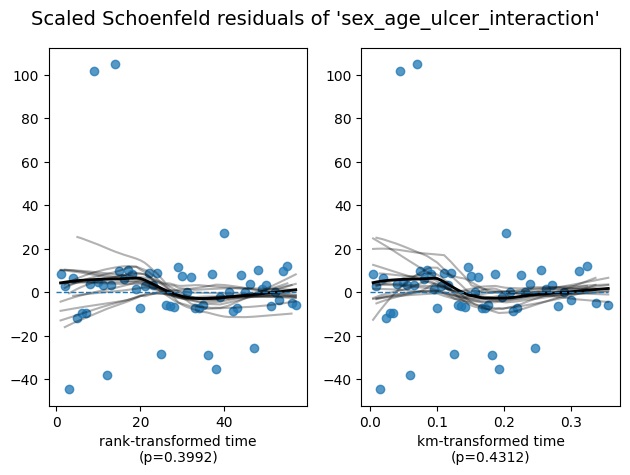

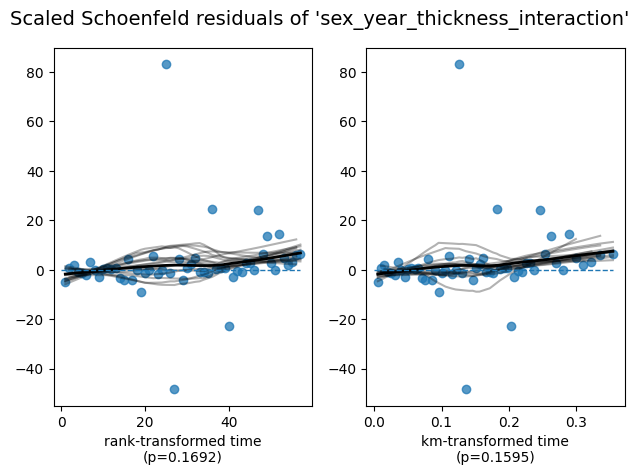

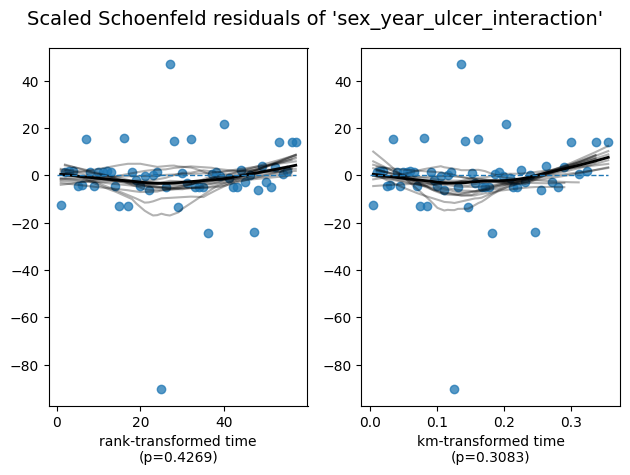

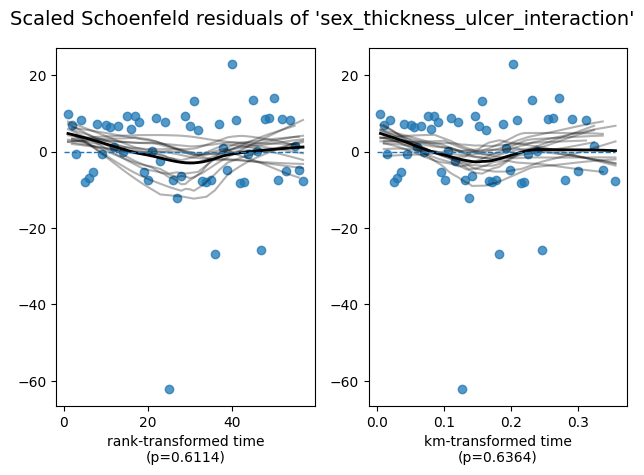

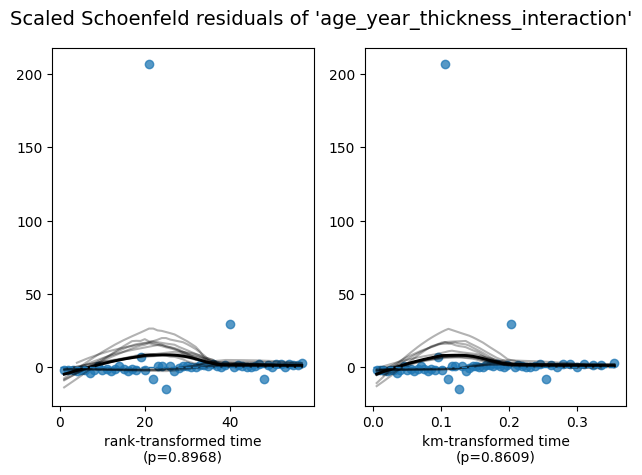

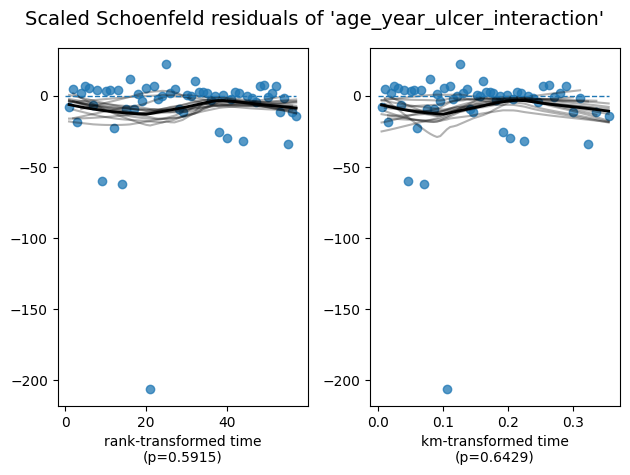

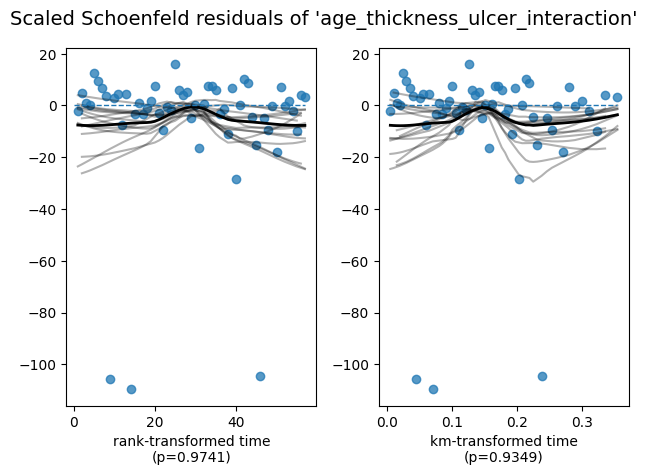

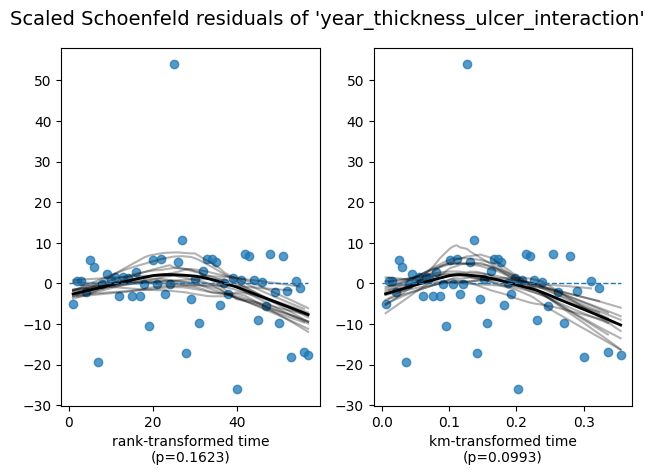

In [ ]:
# Check Residuals For Assumptions - full interaction model
cph_interaction.check_assumptions(
    interaction_data[interaction_columns + ['time', 'event']],
    p_value_threshold=0.05,
    show_plots=True
)


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.3531)'>,
  <Axes: xlabel='km-transformed time\n(p=0.2973)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.7305)'>,
  <Axes: xlabel='km-transformed time\n(p=0.6817)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.8023)'>,
  <Axes: xlabel='km-transformed time\n(p=0.9612)'>]]

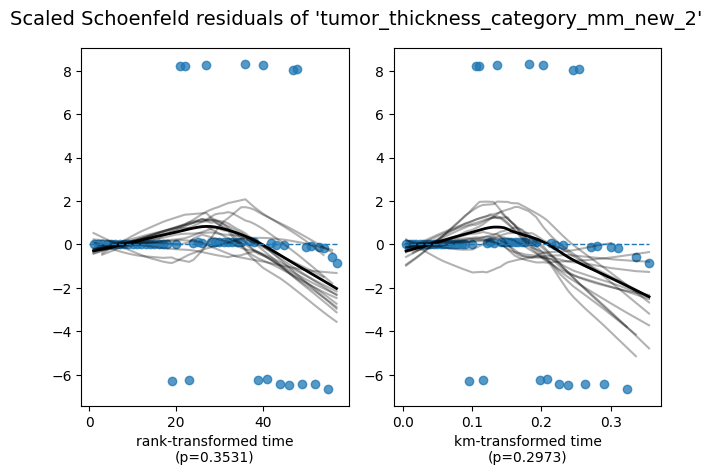

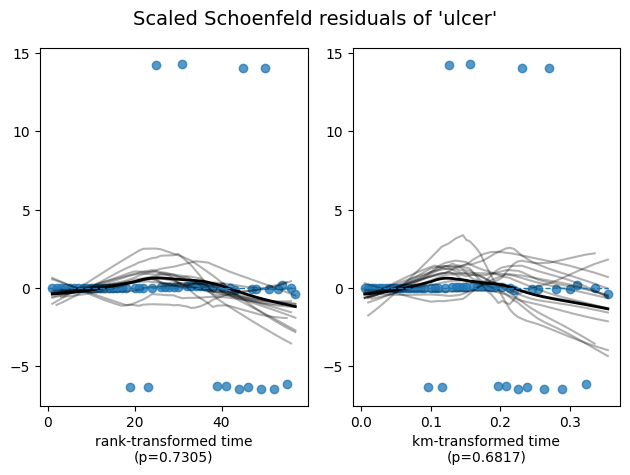

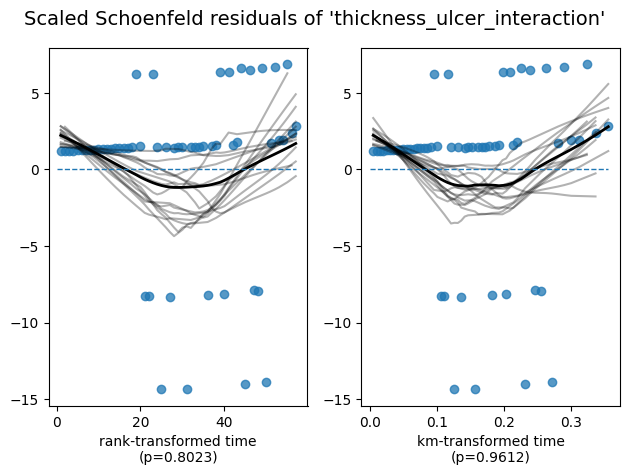

In [ ]:
# Check Residuals For Assumptions - partial interaction model
cph_interaction_elimination.check_assumptions(
    data_after_elimantion[interaction_columns_elimination + ['time', 'event']],
    p_value_threshold=0.05,
    show_plots=True
)

In [ ]:
# Perform backward elimination - full interaction model
selected_vars_full = backward_elimination(interaction_data, duration_col='time', event_col='event')
print("Selected variables:", selected_vars_full)

Removing sex_thickness_ulcer_interaction (p-value = 1.000)
Removing sex_age_thickness_interaction (p-value = 0.956)
Removing year_category (p-value = 0.940)
Removing age_year_interaction (p-value = 0.969)
Removing year (p-value = 0.920)
Removing year_thickness_ulcer_interaction (p-value = 0.939)
Removing sex_thickness_interaction (p-value = 0.897)
Removing sex_year_ulcer_interaction (p-value = 0.879)
Removing sex_year_thickness_interaction (p-value = 0.916)
Removing sex_age_interaction (p-value = 0.829)
Removing sex_age_year_interaction (p-value = 0.897)
Removing sex_year_interaction (p-value = 0.817)
Removing sex (p-value = 0.903)
Removing age_thickness_interaction (p-value = 0.738)
Removing tumor_thickness_category_mm_new_2 (p-value = 0.847)
Removing thickness_year_interaction (p-value = 0.577)
Removing age_thickness_ulcer_interaction (p-value = 0.998)
Removing ulcer (p-value = 0.995)
Removing age_year_thickness_interaction (p-value = 0.182)
Removing age_ulcer_interaction (p-value = 

In [ ]:
# Perform backward elimination - partial interaction model
selected_vars_full2 = backward_elimination(data_after_elimantion, duration_col='time', event_col='event')
print("Selected variables:", selected_vars_full2)

Removing thickness_ulcer_interaction (p-value = 0.397)
Selected variables: ['tumor_thickness_category_mm_new_2', 'ulcer']


In [ ]:
# Data after backward elemination - full and partial interaction model
full_interaction_data_after = interaction_data.drop(columns=[
    'sex_thickness_ulcer_interaction', 'sex_age_thickness_interaction', 'year_category', 'age_year_interaction',
    'year', 'year_thickness_ulcer_interaction', 'sex_thickness_interaction', 'sex_year_ulcer_interaction', 'sex_year_thickness_interaction',
    'sex_age_interaction', 'sex_age_year_interaction', 'sex_year_interaction', 'sex', 'age_thickness_interaction',
    'tumor_thickness_category_mm_new_2', 'thickness_year_interaction', 'age_thickness_ulcer_interaction', 'ulcer',
    'age_year_thickness_interaction', 'age_ulcer_interaction', 'ulcer_year_interaction', 'age_year_ulcer_interaction',
    'sex_ulcer_interaction', 'sex_age_ulcer_interaction', 'age_category_new_1'])

partial_interaction_data_after = data_after_elimantion.drop(columns=['thickness_ulcer_interaction'])

<lifelines.CoxPHFitter: fitted with 205 total observations, 148 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 205
number of events observed = 57
   partial log-likelihood = -263.30
         time fit was run = 2025-01-26 18:18:36 UTC

---
                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                    
thickness_ulcer_interaction  1.71      5.54      0.28            1.17            2.26                3.21                9.57

                             cmp to    z      p  -log2(p)
covariate                                                
thickness_ulcer_interaction    0.00 6.14 <0.005     30.19
---
Concordance = 0.72
Partial AIC = 528.61
log-likelihood ratio test = 39.79 on 1 df
-log2(p) of ll-ratio test = 31.72

<Axes: >

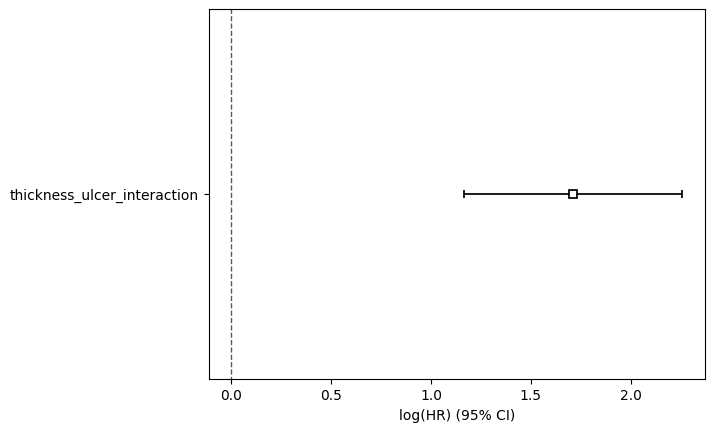

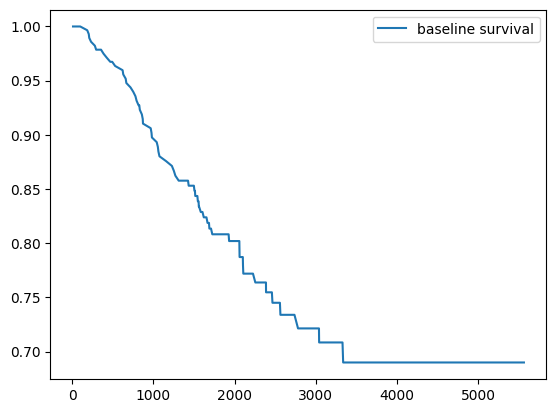

In [ ]:
# CPH for full interaction model after elimination
cph_interaction.fit(full_interaction_data_after, duration_col='time', event_col='event')
cph_interaction.print_summary()
cph_interaction.plot()
cph_interaction.baseline_survival_.plot()

<lifelines.CoxPHFitter: fitted with 205 total observations, 148 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 205
number of events observed = 57
   partial log-likelihood = -262.19
         time fit was run = 2025-01-26 18:18:36 UTC

---
                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                          
ulcer                              0.99      2.69      0.32            0.36            1.62                1.44                5.04
tumor_thickness_category_mm_new_2  1.18      3.24      0.34            0.51            1.85                1.66                6.33

                                   cmp to    z      p  -log2(p)
covariate                                                      
ulcer                                0.00 3.10 <0.005      9.00
tumor_thickness_category_mm_new_2    0.00 3.44 <0.005     10.74
---
Concordance = 0.74
Partial AIC = 528.37
log-likelihood ratio test = 42.03 on 2 df
-log2(p) of ll-ratio test = 30.32

<Axes: >

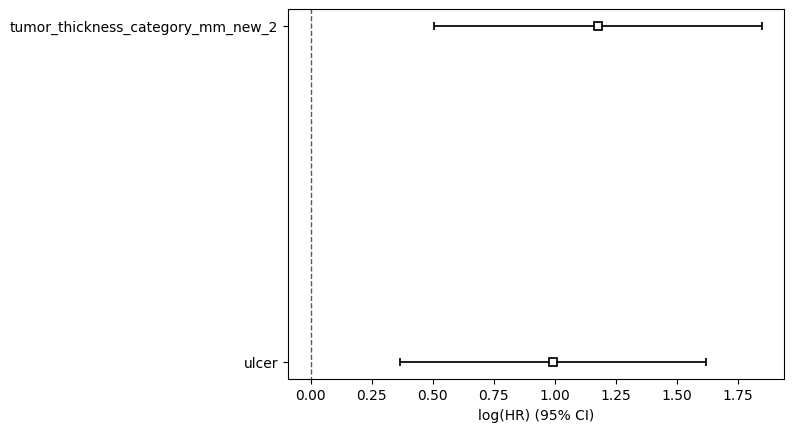

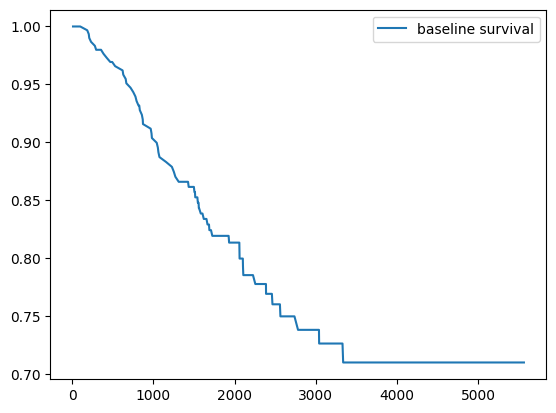

In [ ]:
# CPH for partial interaction model after elimination
cph_interaction_elimination.fit(partial_interaction_data_after, duration_col='time', event_col='event')
cph_interaction_elimination.print_summary()
cph_interaction_elimination.plot()
cph_interaction_elimination.baseline_survival_.plot()


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.



<lifelines.StatisticalResult: proportional_hazard_test>
 null_distribution = chi squared
degrees_of_freedom = 1
             model = <lifelines.CoxPHFitter: fitted with 205 total observations, 148 right-censored observations>
         test_name = proportional_hazard_test

---
                                  test_statistic    p  -log2(p)
thickness_ulcer_interaction km              4.44 0.04      4.83
                            rank            5.67 0.02      5.86



1. Variable 'thickness_ulcer_interaction' failed the non-proportional test: p-value is 0.0173.

   Advice: with so few unique values (only 2), you can include
`strata=['thickness_ulcer_interaction', ...]` in the call in `.fit`. See documentation in link [E]
below.

---
[A]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html
[B]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Bin-variable-and-stratify-on-it
[C]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Introduce-time-varying-covariates
[D]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Modify-the-functional-form
[E]  https://lifelines.readthedocs.io/en/latest/jupyter_notebooks/Proportional%20hazard%20assumption.html#Stratification



[[<Axes: xlabel='rank-transformed time\n(p=0.0173)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0351)'>]]

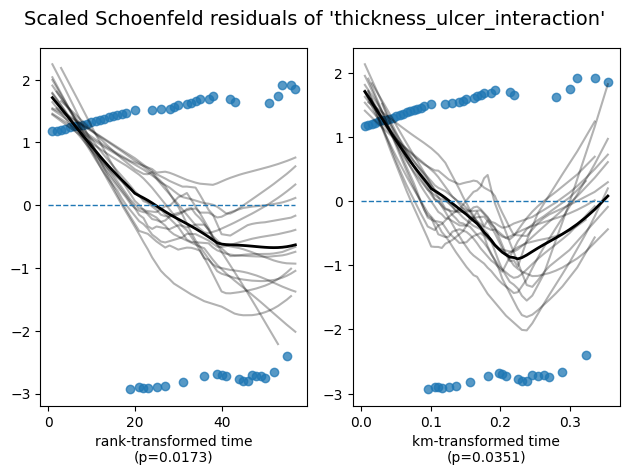

In [ ]:
# Check Residuals For Assumptions - Full interaction model after elimination
cph_interaction.check_assumptions(
    full_interaction_data_after[['thickness_ulcer_interaction'] + ['time', 'event']],
    p_value_threshold=0.05,
    show_plots=True
)

<lifelines.CoxPHFitter: fitted with 205 total observations, 148 right-censored observations>
             duration col = 'time'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 205
number of events observed = 57
   partial log-likelihood = -282.94
         time fit was run = 2025-01-26 18:18:37 UTC

---
                      coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                             
thickness_ulcer_time  0.00      1.00      0.00           -0.00            0.00                1.00                1.00

                      cmp to    z    p  -log2(p)
covariate                                       
thickness_ulcer_time    0.00 0.73 0.46      1.11
---
Concordance = 0.62
Partial AIC = 567.89
log-likelihood ratio test = 0.51 on 1 df
-log2(p) of ll-ratio test = 1.07

<Axes: >

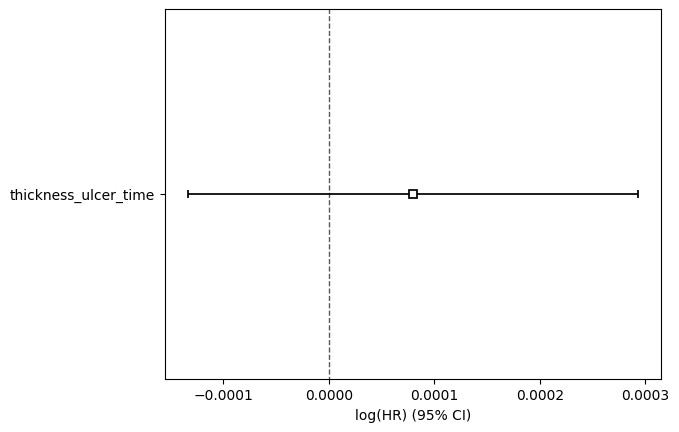

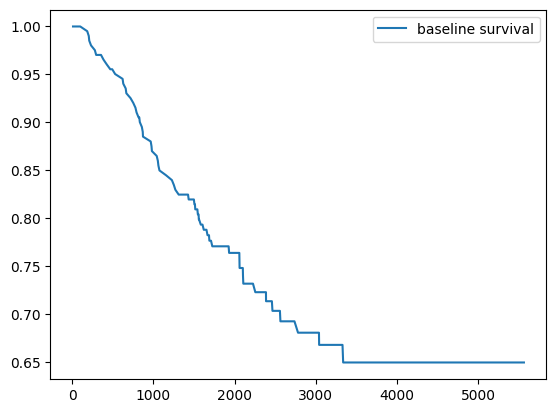

In [ ]:
# Fixing the violation of the assumptions for the full interaction model after elimination
full_interaction_data_after['thickness_ulcer_time'] = full_interaction_data_after['thickness_ulcer_interaction'] * full_interaction_data_after['time']
data_time = full_interaction_data_after[['thickness_ulcer_time'] + ['time', 'event']]
cph_interaction.fit(data_time, duration_col='time', event_col='event')
cph_interaction.print_summary()
cph_interaction.plot()
cph_interaction.baseline_survival_.plot()


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.1476)'>,
  <Axes: xlabel='km-transformed time\n(p=0.0960)'>]]

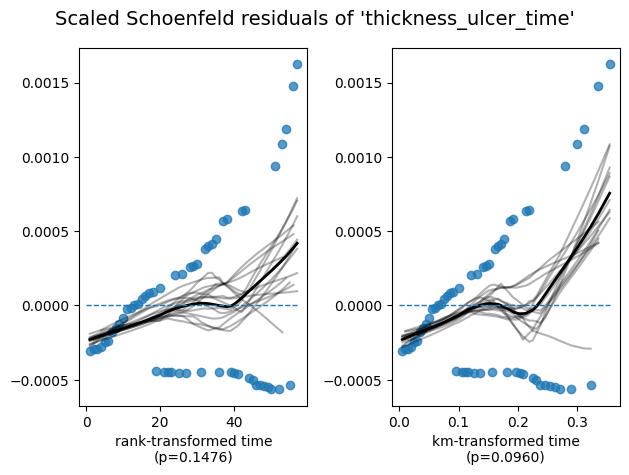

In [ ]:
# Check Residuals For Assumptions - Full interaction model after elimination and fixing
cph_interaction.check_assumptions(
    # full_interaction_data_after[['thickness_ulcer_time'] + ['time', 'event']],
    data_time[['thickness_ulcer_time'] + ['time', 'event']],
    p_value_threshold=0.05,
    show_plots=True
)


   Bootstrapping lowess lines. May take a moment...


   Bootstrapping lowess lines. May take a moment...

Proportional hazard assumption looks okay.


[[<Axes: xlabel='rank-transformed time\n(p=0.2322)'>,
  <Axes: xlabel='km-transformed time\n(p=0.3142)'>],
 [<Axes: xlabel='rank-transformed time\n(p=0.0892)'>,
  <Axes: xlabel='km-transformed time\n(p=0.1012)'>]]

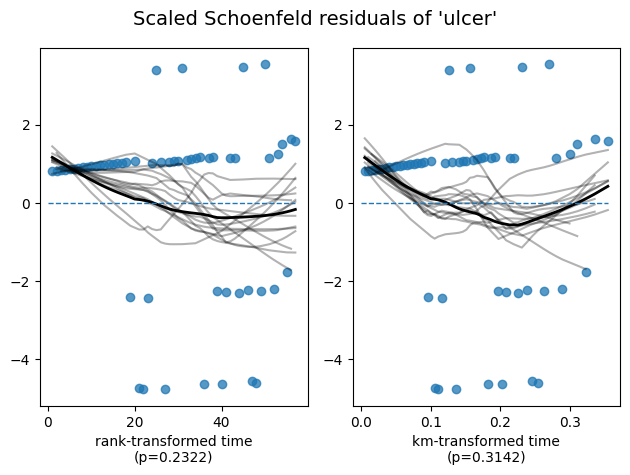

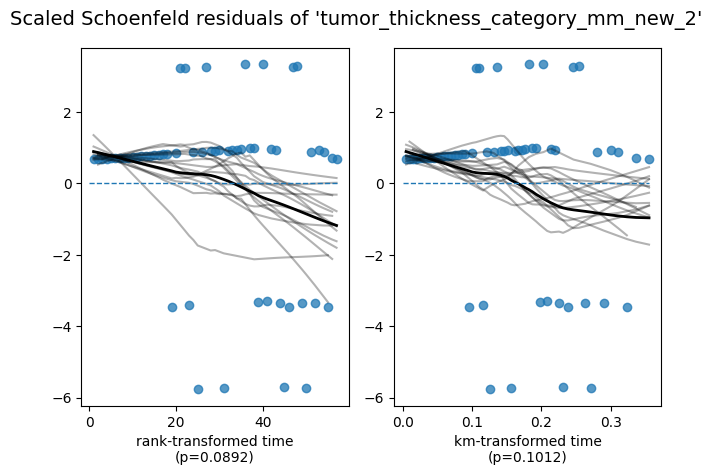

In [ ]:
# Check Residuals For Assumptions - partial interaction model after elimination
cph_interaction_elimination.check_assumptions(
    partial_interaction_data_after[['ulcer', 'tumor_thickness_category_mm_new_2'] + ['time', 'event']],
    p_value_threshold=0.05,
    show_plots=True
)

In [ ]:
# # log likelyhood test for full and partial interaction model (not used explaind in the project)

# # Calculate the test statistic
# log_likelihood_full_after = cph_interaction.log_likelihood_
# log_likelihood_reduced_after = cph_interaction_elimination.log_likelihood_
# test_statistic = 2 * (log_likelihood_reduced_after - log_likelihood_full_after)

# # Degrees of freedom is the difference in the number of parameters between the models
# degrees_of_freedom = len(cph_interaction_elimination.params_) - len(cph_interaction.params_)

# # Calculate the p-value
# p_value = chi2.sf(test_statistic, df=degrees_of_freedom)

# print(f"Likelihood Ratio Test Statistic: {test_statistic}")
# print(f"p-value: {p_value}")
# print(f"Degrees of freedom: {degrees_of_freedom}")
